In [70]:
import os
import sys
import math
import numpy as np
import pandas as pd
from ast import literal_eval
import itertools
import arviz as az
import scipy.stats as st
from scipy.stats import gaussian_kde
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as  mpatches
pd.options.mode.chained_assignment = None  # default='warn'

current_dir = os.getcwd()
helper_path = os.path.abspath(os.path.join(current_dir, '..', 'eye_movement_analysis_moonlander'))
if helper_path not in sys.path:
    sys.path.append(helper_path)

from helper_functions import *

scaling=18

In [56]:
example = pre_process_input_data(pd.read_csv(("../../../../Volumes/KMODyS_1/Data Moonlander IV/KA06EL/KA06EL_output_1_57.csv"), index_col=False))
example

,frame,trial,attempt,time_played,level_size_y,player_pos,collision,current_input,drift_enabled,current_drift,...,adjacent_wall_tiles_x_pos,visible_drift_tiles,prior,SoC,start_input,N_input,input_change,input_duration,drift_tile_onset,drift_effect_onset
0,0,1,1,1.315997,4214,"[707, -67]",False,NaN,True,0.0,...,NaN,[],2,5,NaN,NaN,NaN,NaN,0,0
1,1,1,1,1.332940,4214,"[707, -64]",False,NaN,True,0.0,...,NaN,[],2,5,NaN,NaN,NaN,NaN,0,0
2,2,1,1,1.349563,4214,"[707, -61]",False,NaN,True,0.0,...,NaN,[],2,5,NaN,NaN,NaN,NaN,0,0
3,3,1,1,1.366018,4214,"[707, -58]",False,NaN,True,0.0,...,NaN,[],2,5,NaN,NaN,NaN,NaN,0,0
4,4,1,1,1.382693,4214,"[707, -55]",False,NaN,True,0.0,...,NaN,[],2,5,NaN,NaN,NaN,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
890,890,1,1,16.114076,4214,"[707, 209]",False,NaN,True,0.0,...,NaN,[],2,5,NaN,NaN,NaN,NaN,0,0
891,891,1,1,16.130698,4214,"[707, 209]",False,NaN,True,0.0,...,NaN,[],2,5,NaN,NaN,NaN,NaN,0,0
892,892,1,1,16.147612,4214,"[707, 209]",False,NaN,True,0.0,...,NaN,[],2,5,NaN,NaN,NaN,NaN,0,0
893,893,1,1,16.164921,4214,"[707, 209]",False,NaN,True,0.0,...,NaN,[],2,5,NaN,NaN,NaN,NaN,0,0


"KA06EL_output_1_57.csv" means level=1 and experimental_trial=57

In [57]:
example.columns

Index(['frame', 'trial', 'attempt', 'time_played', 'level_size_y',
       'player_pos', 'collision', 'current_input', 'drift_enabled',
       'current_drift', 'level_done', 'visible_obstacles', 'last_walls_tile',
       'adjacent_wall_tiles_x_pos', 'visible_drift_tiles', 'prior', 'SoC',
       'start_input', 'N_input', 'input_change', 'input_duration',
       'drift_tile_onset', 'drift_effect_onset'],
      dtype='object')

player_pos, current_drift, current_input, drift_onset;
with free fall y move being 5 every frame

In [65]:
data_dir = "../../../../Volumes/KMODyS_1/Data Moonlander IV/"

output_string = "output"
training_string = "training"


runs = []

for subdir, dirs, files in os.walk(data_dir):
    for file in files:
        # potentially only going for crashed or done data
        if training_string not in file and output_string in file:
            runs.append(file)

In [66]:
runs

['BI21RG_output_1_16.csv',
 'BI21RG_output_2_79.csv',
 'BI21RG_output_2_100.csv',
 'BI21RG_output_3_106.csv',
 'BI21RG_output_3_137.csv',
 'BI21RG_output_3_147.csv',
 'BI21RG_output_4_15.csv',
 'BI21RG_output_4_47.csv',
 'BI21RG_output_4_166.csv',
 'BI21RG_output_5_70.csv',
 'BI21RG_output_6_24.csv',
 'BI21RG_output_7_02.csv',
 'BI21RG_output_7_20.csv',
 'BI21RG_output_7_25.csv',
 'BI21RG_output_8_107.csv',
 'BI21RG_output_8_118.csv',
 'BI21RG_output_8_120.csv',
 'BI21RG_output_9_19.csv',
 'BI21RG_output_9_31.csv',
 'BI21RG_output_10_23.csv',
 'BI21RG_output_10_66.csv',
 'BI21RG_output_10_90.csv',
 'BI21RG_output_11_40.csv',
 'BI21RG_output_11_117.csv',
 'BI21RG_output_12_112.csv',
 'BI21RG_output_12_168.csv',
 'BI21RG_output_13_11.csv',
 'BI21RG_output_13_128.csv',
 'BI21RG_output_13_175.csv',
 'BI21RG_output_14_78.csv',
 'BI21RG_output_14_163.csv',
 'BI21RG_output_15_42.csv',
 'BI21RG_output_16_22.csv',
 'BI21RG_output_16_99.csv',
 'BI21RG_output_16_111.csv',
 'BI21RG_output_17_26.cs

In [68]:
all_data = []

for run in runs:
    
    tmp = run.split('_')
    id_code = tmp[0]
    level = int(tmp[2])
    exp_trial = tmp[-1][:-4]
    
    path = data_dir + str(id_code) + "/"
    
    tmp_input_data = pre_process_input_data(pd.read_csv((f"{path}/{run}"), index_col=False))
    
    player_positions = tmp_input_data["player_pos"]

    x_vals = [pos[0] if isinstance(pos, (list, tuple)) and len(pos) > 0 else np.nan for pos in player_positions]
    
    # drop missing values and keep only the first N values
    x_vals = [x for x in x_vals if pd.notna(x)]
    
    # match to y = 0, 5, 10, ... (pixel values), same length as x_vals
    y_vals = list(range(0, len(x_vals) * 5, 5))

    tmp_df = pd.DataFrame({
        'id': id_code,
        'exp_trial': exp_trial,
        'level': level,
        'x': x_vals,
        'y': y_vals,
        'crashed': tmp_input_data.collision,
        'drift_onset': tmp_input_data.drift_effect_onset,
        'current_drift': tmp_input_data.current_drift,
        'current_input': tmp_input_data.current_input,
        'wall_tile': tmp_input_data.last_walls_tile
    })
    
    tmp_df['drift_id'] = tmp_df['drift_onset'].cumsum()
    tmp_df.loc[tmp_df['drift_onset'] == 0, 'drift_id'] = np.nan
    
    all_data.append(tmp_df)

In [69]:
combined_df = pd.concat(all_data, ignore_index=True)

In [70]:
#combined_df.to_parquet("combined_data.parquet", index=False)

In [44]:
df = pd.read_parquet("combined_data.parquet")
df

,id,exp_trial,level,x,y,crashed,drift_onset,current_drift,current_input,wall_tile,drift_id,relative_x
0,AN02EN,077,1,945,0,False,0,0.0,None,"[1323, 5400]",NaN,378
1,AN02EN,077,1,945,5,False,0,0.0,None,"[1323, 5400]",NaN,378
2,AN02EN,077,1,945,10,False,0,0.0,None,"[1323, 5400]",NaN,378
3,AN02EN,077,1,945,15,False,0,0.0,None,"[1323, 5400]",NaN,378
4,AN02EN,077,1,945,20,False,0,0.0,None,"[1323, 5400]",NaN,378
...,...,...,...,...,...,...,...,...,...,...,...,...
2786510,TA31LN,142,80,707,2630,False,0,1.0,None,"[1021, 2025]",NaN,398
2786511,TA31LN,142,80,707,2635,False,0,1.0,None,"[1026, 2020]",NaN,403
2786512,TA31LN,142,80,707,2640,False,0,1.0,None,"[1031, 2015]",NaN,408
2786513,TA31LN,142,80,707,2645,True,0,1.0,None,"[1036, 2010]",NaN,413


In [3]:
df.columns

Index(['id', 'exp_trial', 'level', 'x', 'y', 'crashed', 'drift_onset',
       'current_drift', 'current_input', 'wall_tile', 'drift_id',
       'relative_x'],
      dtype='object')

In [45]:
# relative x: because horizontal position is kept constant, ...
# we have to compute the horizontal position relative to the wall tile
level_width = 40*scaling  # 40 as fixed variable when generating the levels
df['relative_x'] = df.apply(lambda row: level_width - (row['wall_tile'][0] - row['x']), axis=1)

In [46]:
np.min(df['relative_x'])

-24

spaceship can fly outside wall while crashing because of condition of 3 frames with collision.

In [47]:
# it seems like the reference point changed over trials over participants...

corrected_dfs = []

level_groups = df.groupby('level')

for level, level_df in level_groups:
    
    # 1. extract y == 0 rows for this level
    y0_df = level_df[level_df['y'] == 0]
    
    # 2. get maximum relative_x at y = 0 (the reference)
    reference_x = y0_df['relative_x'].max()
    
    # 3. group by 'id' and 'exp_trial' within this level
    trial_groups = level_df.groupby(['id', 'exp_trial'])
    
    for (id_val, trial_val), trial_df in trial_groups:
        
        # a) get this group's relative_x at y = 0
        trial_y0 = trial_df[trial_df['y'] == 0]
        
        # get the relative_x where y == 0
        try:
            trial_start_x = trial_df.loc[trial_df['y'] == 0, 'relative_x'].iloc[0]
        except IndexError:
            # no y == 0 in this trial -> skip correction
            corrected_dfs.append(trial_df)
            continue
        
        # b) compute offset
        offset = reference_x - trial_start_x
        
        # c) apply offset to all relative_x
        trial_df = trial_df.copy()
        trial_df['relative_x'] = trial_df['relative_x'] + offset
        
        corrected_dfs.append(trial_df)

corrected_df = pd.concat(corrected_dfs, ignore_index=True)


In [48]:
corrected_df.columns

Index(['id', 'exp_trial', 'level', 'x', 'y', 'crashed', 'drift_onset',
       'current_drift', 'current_input', 'wall_tile', 'drift_id',
       'relative_x'],
      dtype='object')

In [49]:
#corrected_df.to_parquet("combined_data.parquet", index=False)

# Generating distributions of drift-section entry points

In [50]:
drift_onset_data = corrected_df[corrected_df.drift_onset == 1]
drift_onset_data

,id,exp_trial,level,x,y,crashed,drift_onset,current_drift,current_input,wall_tile,drift_id,relative_x
241,AN02EN,077,1,945,1205,False,1,-1.0,None,"[1551, 4482]",1.0,198
439,AN02EN,077,1,945,2195,False,1,-1.0,None,"[1425, 3294]",2.0,324
728,AN02EN,082,1,945,1205,False,1,-1.0,Left,"[1437, 4482]",1.0,312
997,AN02EN,124,1,945,1205,False,1,-1.0,Left,"[1539, 4482]",1.0,210
1195,AN02EN,124,1,945,2195,False,1,-1.0,None,"[1401, 3294]",2.0,348
...,...,...,...,...,...,...,...,...,...,...,...,...
2785827,TA31LN,131,80,707,1870,False,1,-1.0,None,"[1001, 2785]",2.0,426
2785967,TA31LN,131,80,707,2570,False,1,1.0,None,"[966, 2085]",3.0,461
2786185,TA31LN,142,80,707,1005,False,1,-1.0,None,"[1086, 3650]",1.0,341
2786358,TA31LN,142,80,707,1870,False,1,-1.0,None,"[991, 2785]",2.0,436


In [62]:
relative_x_distributions = (
    drift_onset_data
    .groupby(['level', 'drift_id'])['relative_x']
    .apply(lambda x: np.array(x))
    .reset_index(name='relative_x_distribution')
)

In [63]:
relative_x_distributions

,level,drift_id,relative_x_distribution
0,1,1.0,"[198, 312, 210, 251, 738, 246, 198, 180, 192, ..."
1,1,2.0,"[324, 348, 446, 396, 216, 306, 396, 516, 516, ..."
2,1,3.0,"[612, 526, 588, 624, 564, 552, 486, 528, 618, ..."
3,1,4.0,"[630, 536, 630, 744, 762, 504, 450, 660, 534, ..."
4,2,1.0,"[594, 618, 618, 551, 556, 546, 588, 612, 648, ..."
...,...,...,...
315,79,4.0,"[600, 642, 536, 630, 708, 510, 528, 636, 552, ..."
316,80,1.0,"[276, 391, 331, 132, 750, 126, 234, 390, 486, ..."
317,80,2.0,"[378, 411, 416, 354, 336, 474, 312, 378, 426, ..."
318,80,3.0,"[762, 531, 681, 690, 738, 552, 726, 714, 762, ..."


In [64]:
#relative_x_distributions.to_parquet("relative_x_distributions.parquet", index=False)

In [97]:
filename = "simulation_output_1_00.csv"

# read-in and preprocess simulation data
sim_dat = pre_process_input_data(pd.read_csv(filename))

tmp = filename.split('_')
level = int(tmp[2])
exp_trial = tmp[-1][:-4]

#sim_dat["player_pos"] = sim_dat.player_pos.apply(lambda x: literal_eval(x))
player_positions = sim_dat["player_pos"]

x_vals = [pos[0] if isinstance(pos, (list, tuple)) and len(pos) > 0 else np.nan for pos in player_positions]

# drop missing values and keep only the first N values
x_vals = [x for x in x_vals if pd.notna(x)]
sim_dat['x'] = x_vals

# relative_x
#sim_dat["last_walls_tile"] = sim_dat.last_walls_tile.apply(lambda x: literal_eval(x))
level_width = 40*scaling  # 40 as fixed variable when generating the levels
sim_dat['relative_x'] = sim_dat.apply(lambda row: level_width - (row['last_walls_tile'][0] - row['x']), axis=1)

# match to y = 0, 5, 10, ... (pixel values), same length as x_vals
y_vals = list(range(0, len(x_vals) * 5, 5))

sim_dat['y'] = y_vals


# compute offset of simulated dataset, because drawing on screen may have variance
start_xs = corrected_df[(corrected_df['level'] == level) & (corrected_df['y'] == 0 )].relative_x
if np.all(start_xs == start_xs[0]):
    reference_x = start_xs[0]
else:
    reference_x = start_xs.max()
    print("found variance in relative x positional data between trials")

offset = reference_x - sim_dat.iloc[0].relative_x
sim_dat.relative_x = sim_dat.relative_x + offset

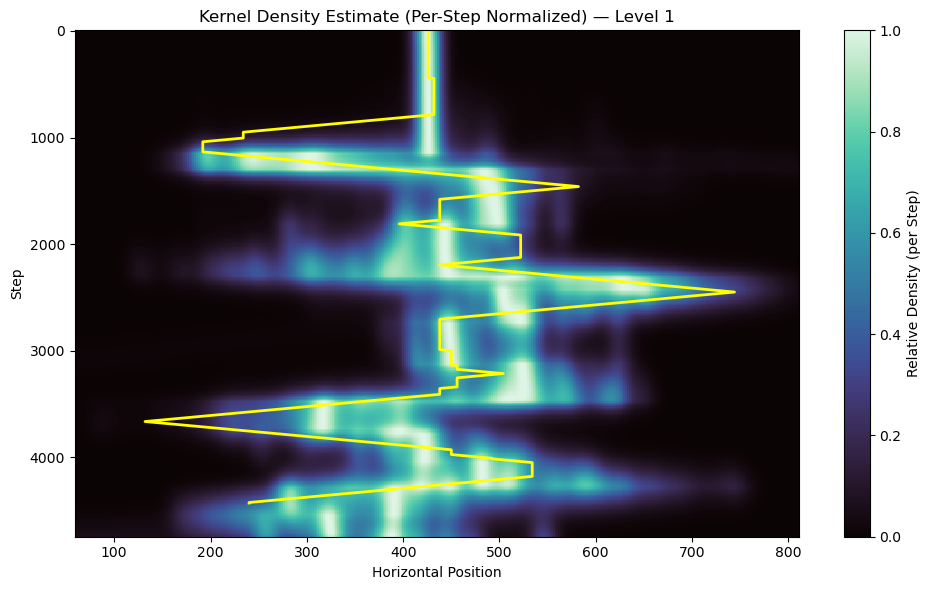

In [98]:
# plotting
group = corrected_df[corrected_df.level == level]
    
x = group['relative_x'].values
y = group['y'].values

# grid (binning)
x_bins = np.linspace(x.min(), x.max(), 400)
y_bins = np.linspace(y.min(), y.max(), 400)
X, Y = np.meshgrid(x_bins, y_bins)
positions = np.vstack([X.ravel(), Y.ravel()])

# compute KDE
kde = gaussian_kde(np.vstack([x, y]), bw_method=0.1)  # controls smoothing
Z = kde(positions).reshape(X.shape)

# normalize by row (per y-bin)
Z_norm = Z / Z.max(axis=1, keepdims=True)
Z_norm = np.nan_to_num(Z_norm)

# plotting
plt.figure(figsize=(10, 6))
plt.pcolormesh(X, Y, Z_norm, shading='auto', cmap='mako')
plt.gca().invert_yaxis()

# overlay sim_dat points
plt.plot(sim_dat['relative_x'], sim_dat['y'], color='yellow', linewidth=2, label='simulated data')

plt.colorbar(label='Relative Density (per Step)')
plt.xlabel('Horizontal Position')
plt.ylabel('Step')
plt.title(f'Kernel Density Estimate (Per-Step Normalized) — Level {level}')
plt.tight_layout()
plt.show()


### Comparing entry point distributions

In [102]:
sim_dat.columns

Index(['frame', 'trial', 'attempt', 'time_played', 'level_size_y',
       'player_pos', 'collision', 'current_input', 'drift_enabled',
       'current_drift', 'level_done', 'visible_obstacles', 'last_walls_tile',
       'adjacent_wall_tiles_x_pos', 'visible_drift_tiles', 'prior', 'SoC',
       'action_goal_x', 'start_input', 'N_input', 'input_change',
       'input_duration', 'drift_tile_onset', 'drift_effect_onset', 'x',
       'relative_x', 'y'],
      dtype='object')

In [118]:
drift_entry_points_sim = sim_dat[sim_dat.drift_effect_onset == 1]

level_dat = relative_x_distributions[relative_x_distributions.level == level]

In [119]:
level_dat

,level,drift_id,relative_x_distribution
0,1,1.0,"[198, 312, 210, 251, 738, 246, 198, 180, 192, ..."
1,1,2.0,"[324, 348, 446, 396, 216, 306, 396, 516, 516, ..."
2,1,3.0,"[612, 526, 588, 624, 564, 552, 486, 528, 618, ..."
3,1,4.0,"[630, 536, 630, 744, 762, 504, 450, 660, 534, ..."


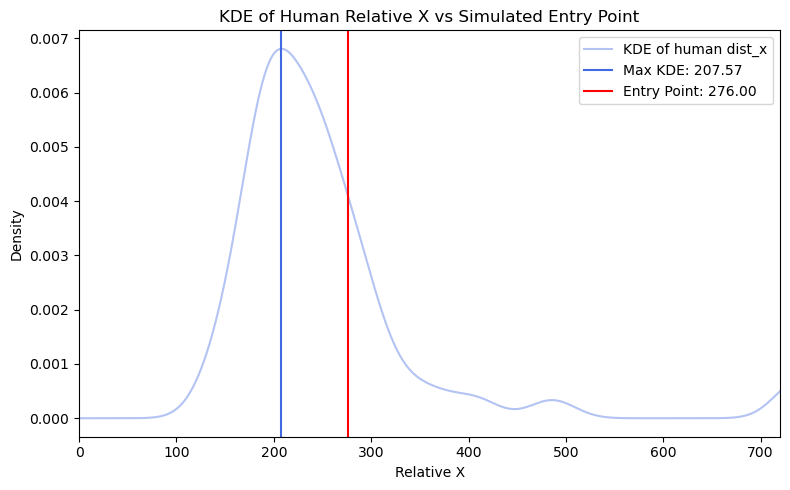

Max KDE position: 207.57
Entry Point: 276.00
Absolute Difference: 68.43
Percentage Deviation: 9.50%


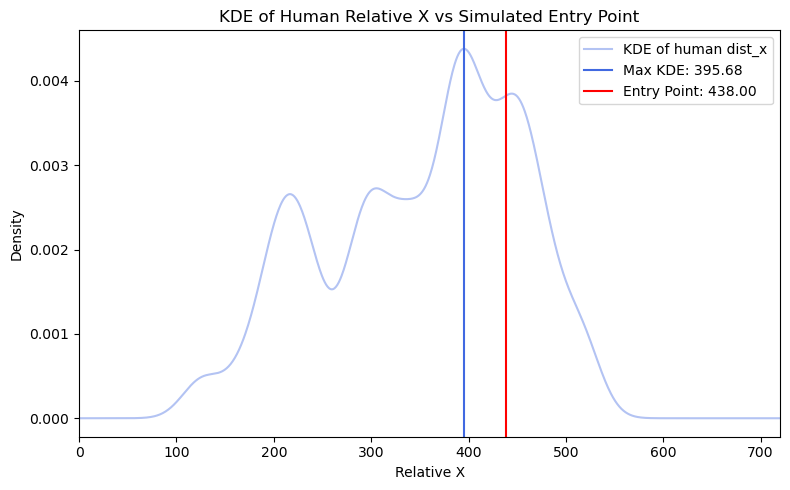

Max KDE position: 395.68
Entry Point: 438.00
Absolute Difference: 42.32
Percentage Deviation: 5.88%


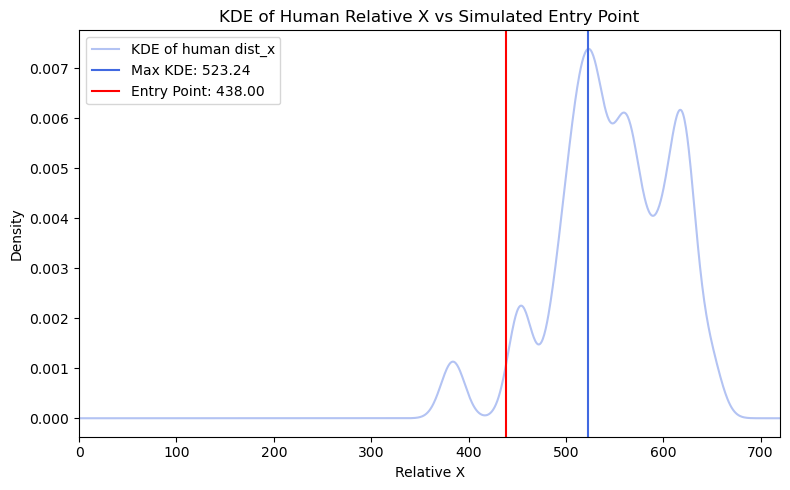

Max KDE position: 523.24
Entry Point: 438.00
Absolute Difference: 85.24
Percentage Deviation: 11.84%


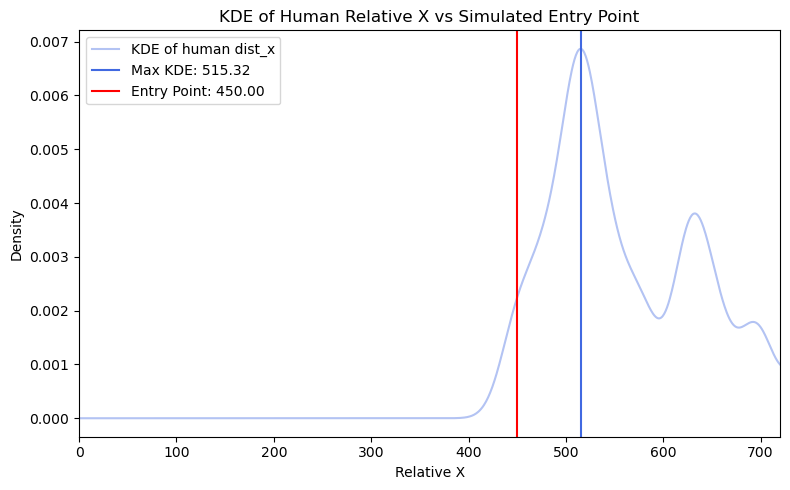

Max KDE position: 515.32
Entry Point: 450.00
Absolute Difference: 65.32
Percentage Deviation: 9.07%


In [135]:
for id_, row in drift_entry_points_sim.reset_index().iterrows():
    entry_point_x = row.relative_x
    
    dist_x = level_dat[level_dat.drift_id == id_+1].relative_x_distribution.values[0]  # super ugly...
    
    #  KDE for dist_x
    kde = gaussian_kde(dist_x, bw_method=0.2)  # adjust bw_method for smoothness
    x_range = np.linspace(0, level_width, 1000)
    kde_values = kde(x_range)

    # find x at max density
    x_kde_max = x_range[np.argmax(kde_values)]

    # plotting
    plt.figure(figsize=(8, 5))
    plt.plot(x_range, kde_values, color='royalblue', label='KDE of human dist_x', alpha=0.4)
    plt.axvline(x_kde_max, color='royalblue', linestyle='-', label=f'Max KDE: {x_kde_max:.2f}')
    plt.axvline(entry_point_x, color='red', linestyle='-', label=f'Entry Point: {entry_point_x:.2f}')
    plt.xlim(0, level_width)
    plt.xlabel('Relative X')
    plt.ylabel('Density')
    plt.title('KDE of Human Relative X vs Simulated Entry Point')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # compute percentage deviation
    max_possible_dev = level_width
    abs_diff = abs(entry_point_x - x_kde_max)
    percentage_dev = (abs_diff / max_possible_dev) * 100

    print(f"Max KDE position: {x_kde_max:.2f}")
    print(f"Entry Point: {entry_point_x:.2f}")
    print(f"Absolute Difference: {abs_diff:.2f}")
    print(f"Percentage Deviation: {percentage_dev:.2f}%")

# Bayesian success modeling per drift

In [192]:
records = []

grouped = corrected_df.groupby(['id', 'exp_trial'])

for (pid, trial), group in grouped:
    group = group.sort_values('y')
    
    drift_rows = group[group['drift_id'].notna()].copy()
    drift_rows['drift_id'] = drift_rows['drift_id'].astype(int)
    
    # handle no drift seen at all
    if drift_rows.empty:
        last_successful = 0
    
    else:
        crash_rows = group[group['crashed'] == True]
        
        if crash_rows.empty:
            # no crash: success = number of unique drift sections seen
            last_successful = drift_rows['drift_id'].nunique()
        else:
            # crash happened: count only drifts that occurred BEFORE the crash
            crash_time = crash_rows.iloc[0]['y']
            drifts_before_crash = drift_rows[drift_rows['y'] < crash_time]
            last_successful = drifts_before_crash['drift_id'].nunique()
    
    records.append({
        'id': pid,
        'exp_trial': trial,
        'success_count': last_successful
    })

trial_level_df = pd.DataFrame(records)
trial_level_df['trial_index'] = trial_level_df.groupby('id').cumcount()


In [193]:
trial_level_df['success_count'].mean()

2.5040098704503393

In [194]:
trial_level_df['success_count'].value_counts()

success_count
4    1622
1    1405
2    1176
3     644
0      16
Name: count, dtype: int64

In [198]:
trial_level_df.columns

Index(['id', 'exp_trial', 'success_count', 'trial_index'], dtype='object')

## Bayes modeling

### Per drift success prob

In [161]:
# convert ids to categorical codes for indexing
model_df['id_code'] = model_df['id'].astype('category').cat.codes
model_df['drift_code'] = model_df['drift_id'] - 1  # 0-based

n_participants = model_df['id_code'].nunique()
n_drifts = 4
n_obs = len(model_df)

In [162]:
import pymc3 as pm
import theano.tensor as tt

with pm.Model() as model:

    # hyperpriors for intercepts and slopes
    mu_alpha = pm.Normal('mu_alpha', mu=0, sigma=2)
    sigma_alpha = pm.Exponential('sigma_alpha', 1)
    
    mu_beta = pm.Normal('mu_beta', mu=0, sigma=1)
    sigma_beta = pm.Exponential('sigma_beta', 1)

    # individual intercepts and slopes per participant and drift section
    alpha = pm.Normal('alpha', mu=mu_alpha, sigma=sigma_alpha, shape=(n_participants, n_drifts))
    beta = pm.Normal('beta', mu=mu_beta, sigma=sigma_beta, shape=(n_participants, n_drifts))

    # expected success probability
    logit_p = alpha[model_df['id_code'].values, model_df['drift_code'].values] + \
              beta[model_df['id_code'].values, model_df['drift_code'].values] * \
              model_df['trial_index'].values

    p = pm.Deterministic('p', pm.math.sigmoid(logit_p))

    # Likelihood
    success = pm.Bernoulli('success', p=p, observed=model_df['success'].values)

    trace = pm.sample(2000, tune=1000, target_accept=0.9, cores=2, random_seed=36)


/var/folders/z1/crk0j_p52yq850yynjpq93wm0000gn/T/ipykernel_17032/3584417034.py:27: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  trace = pm.sample(2000, tune=1000, target_accept=0.9, cores=2, random_seed=36)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta, alpha, sigma_beta, mu_beta, sigma_alpha, mu_alpha]


/Users/heinrich/anaconda3/envs/datascience/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 688 seconds.
There were 610 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6349422533769914, but should be close to 0.9. Try to increase the number of tuning steps.
The rhat statistic is larger than 1.05 for some parameters. This indicates slight problems during sampling.
The estimated number of effective samples is smaller than 200 for some parameters.


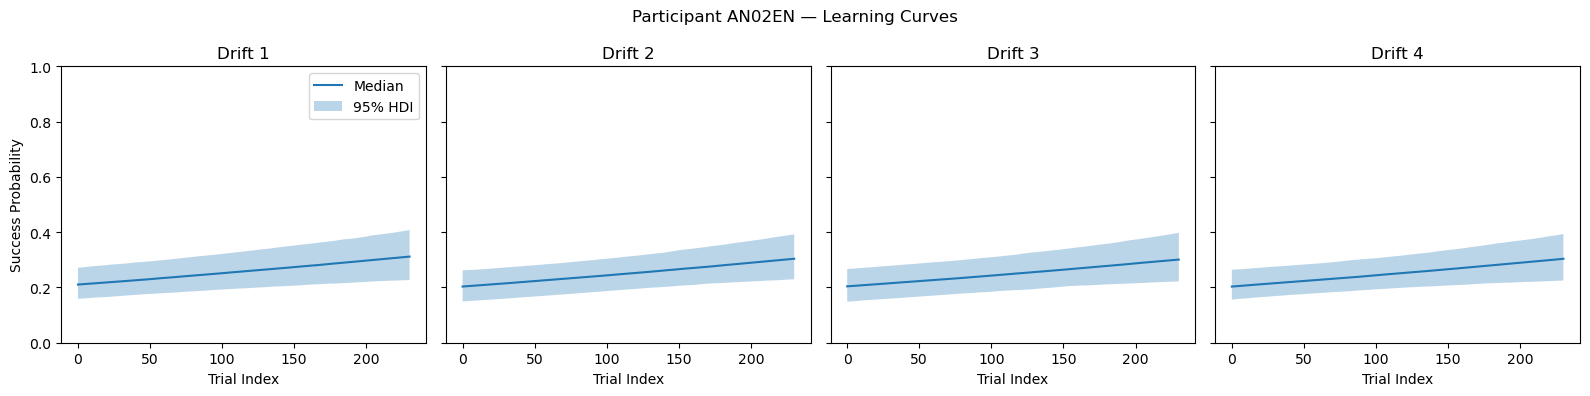

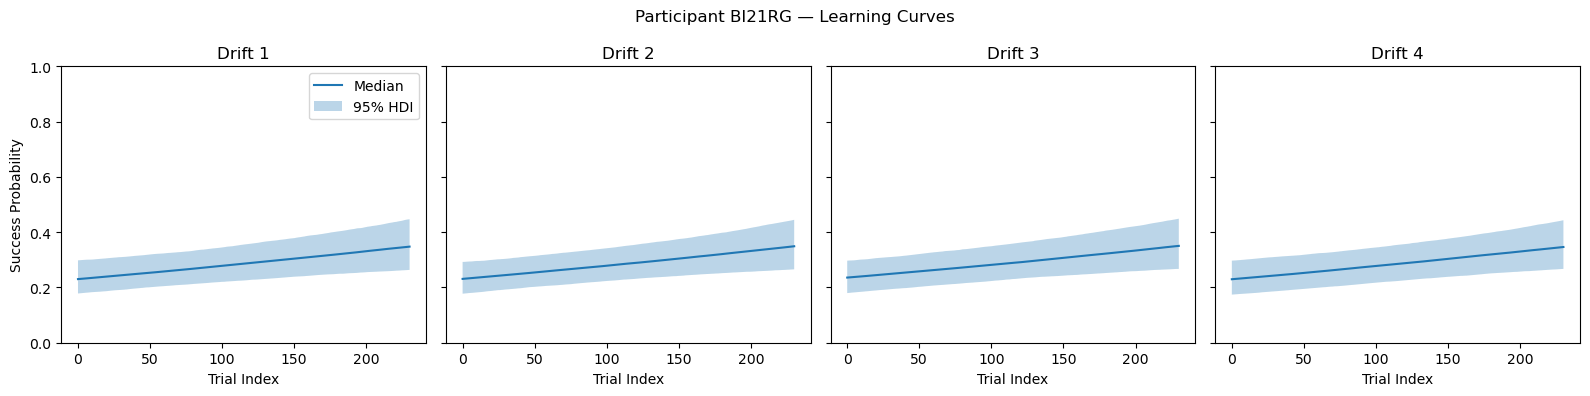

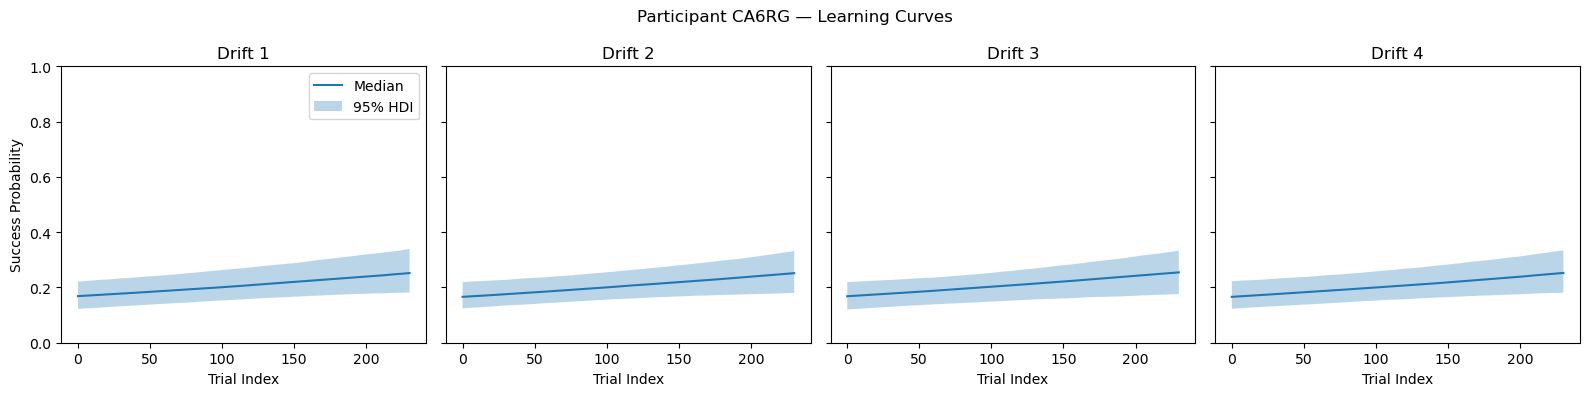

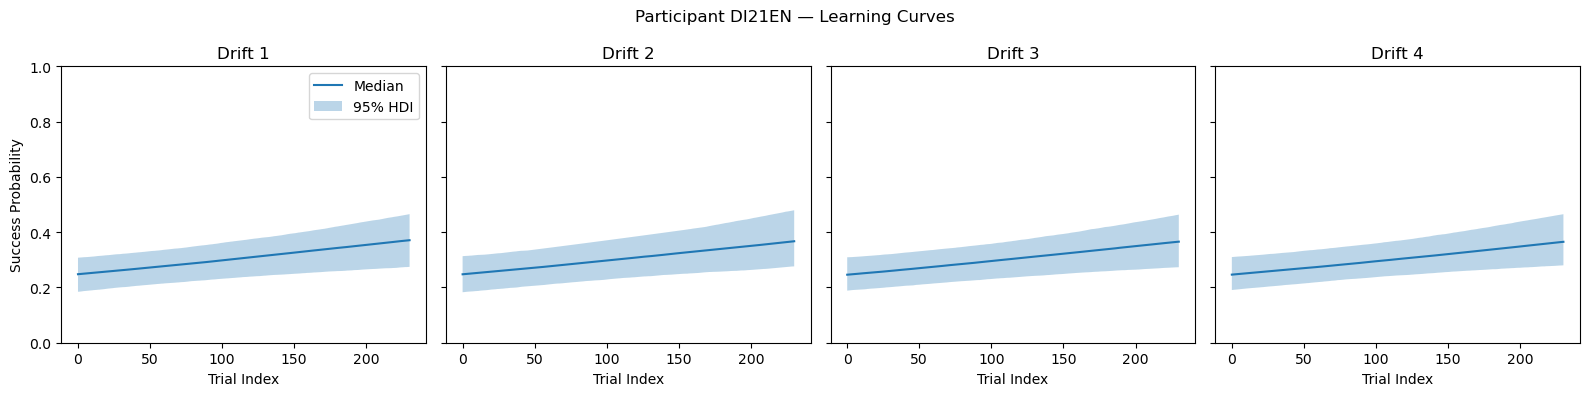

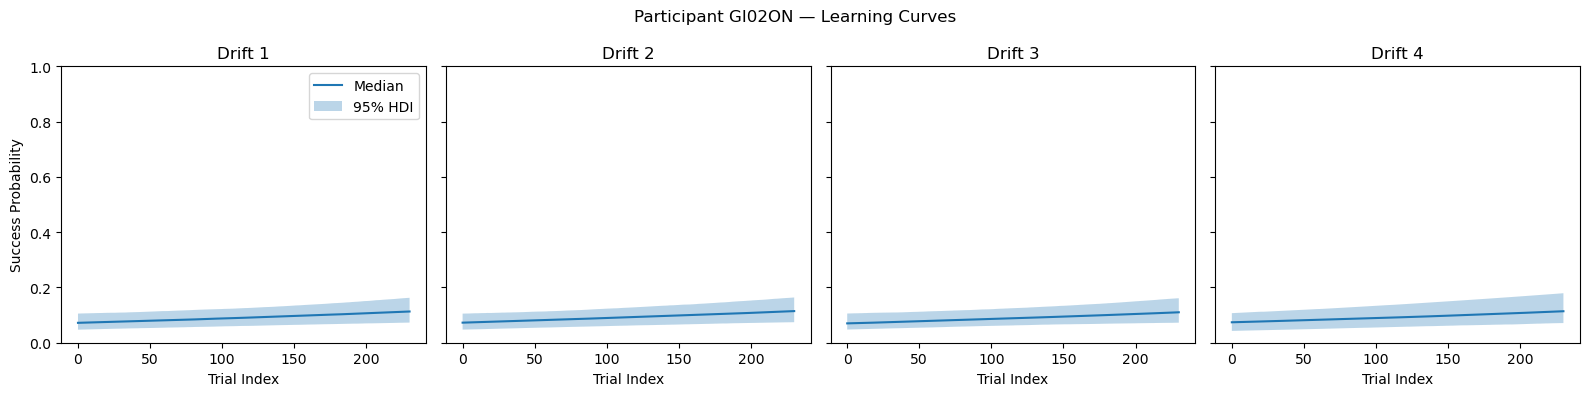

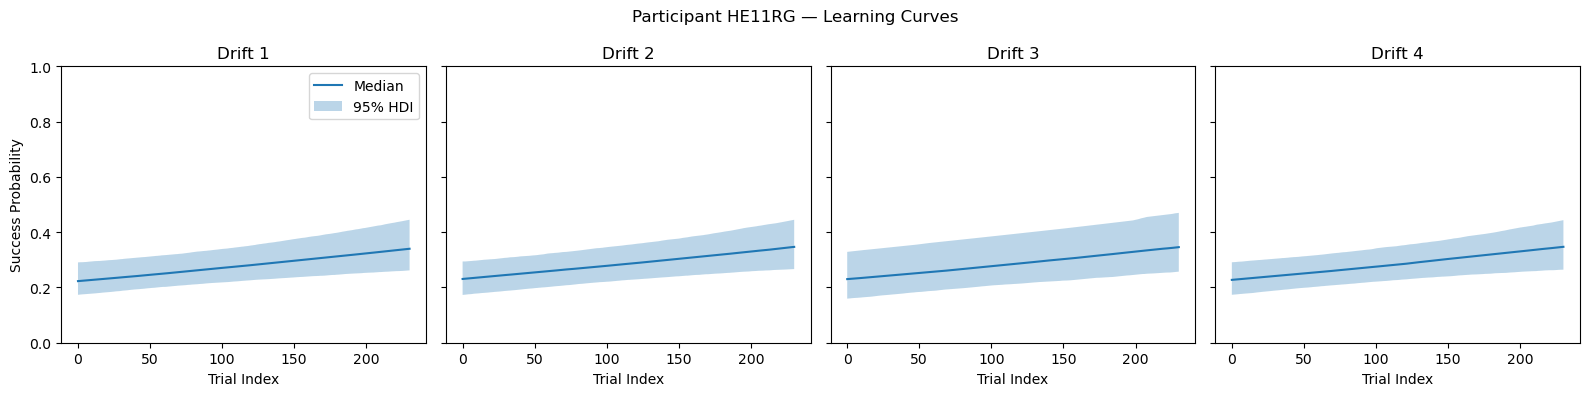

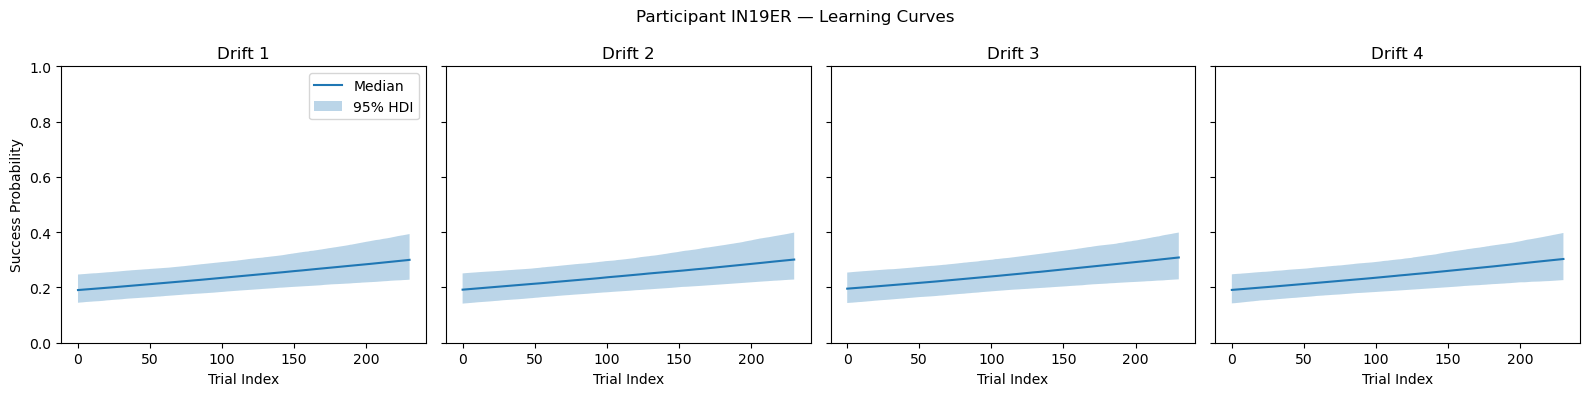

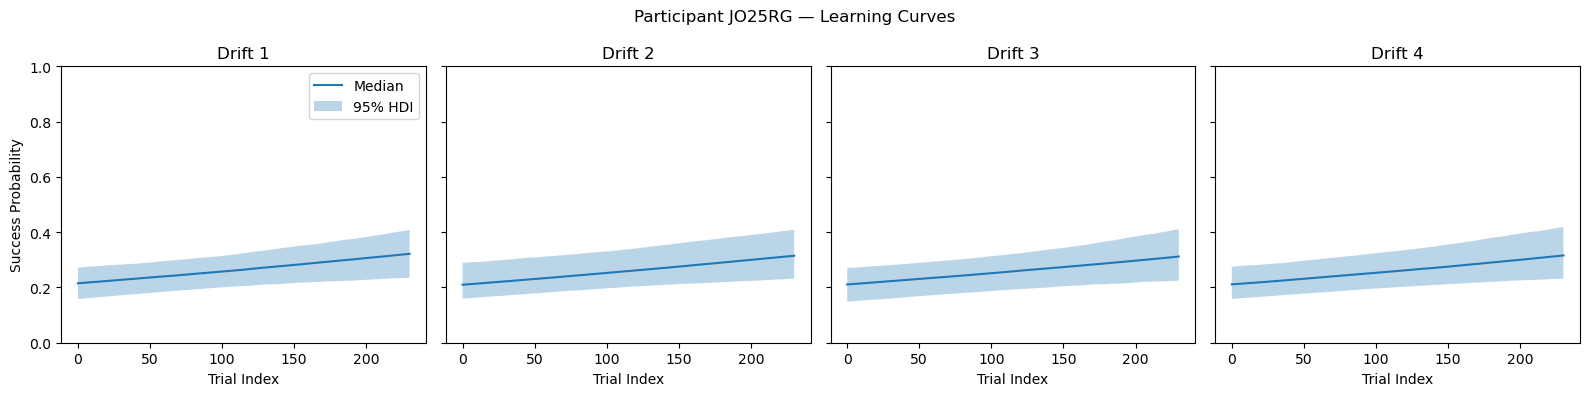

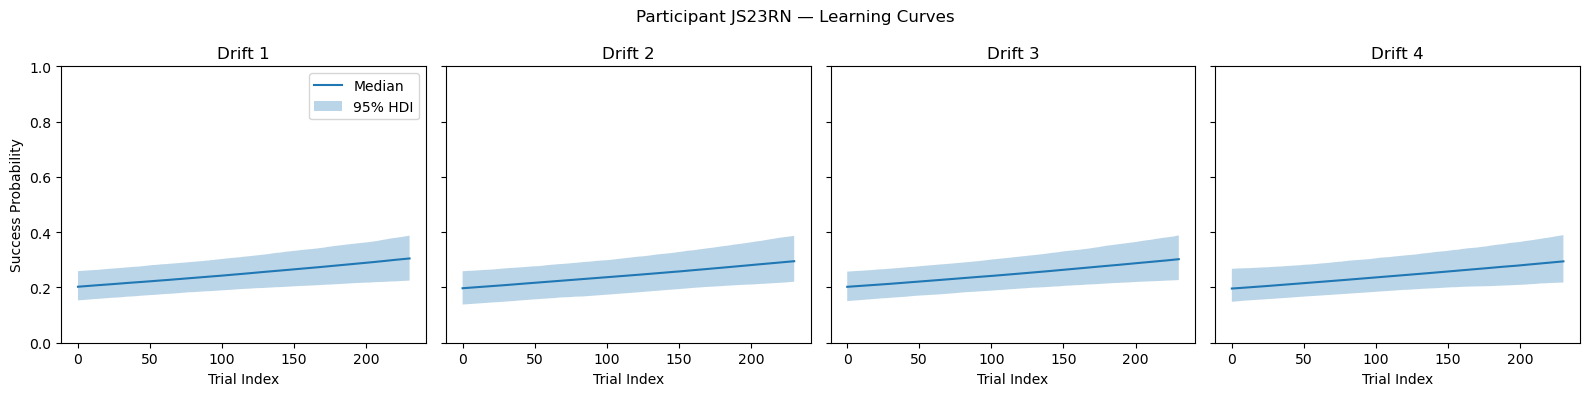

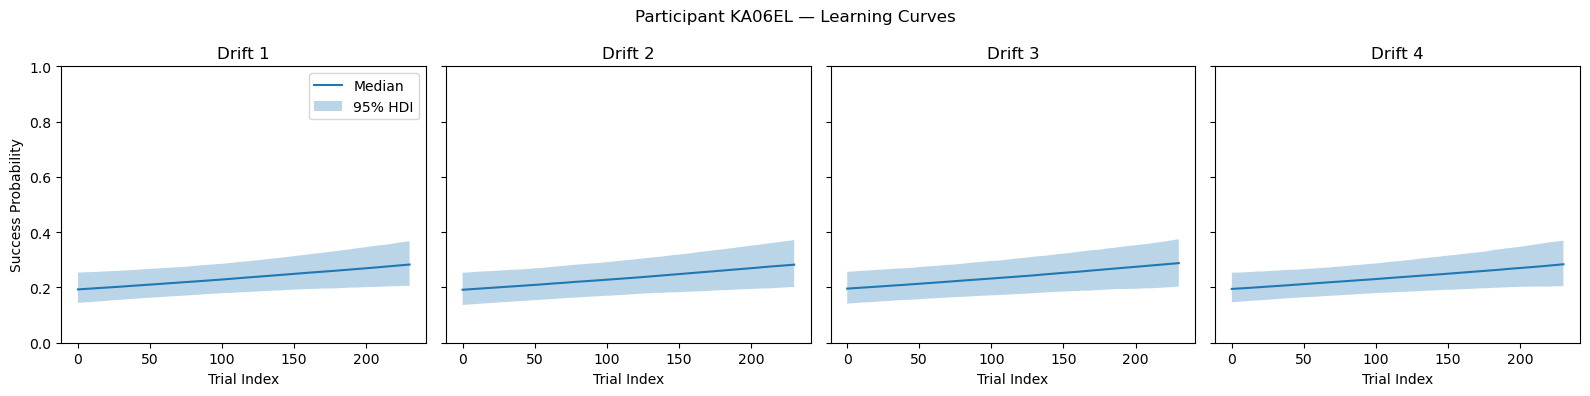

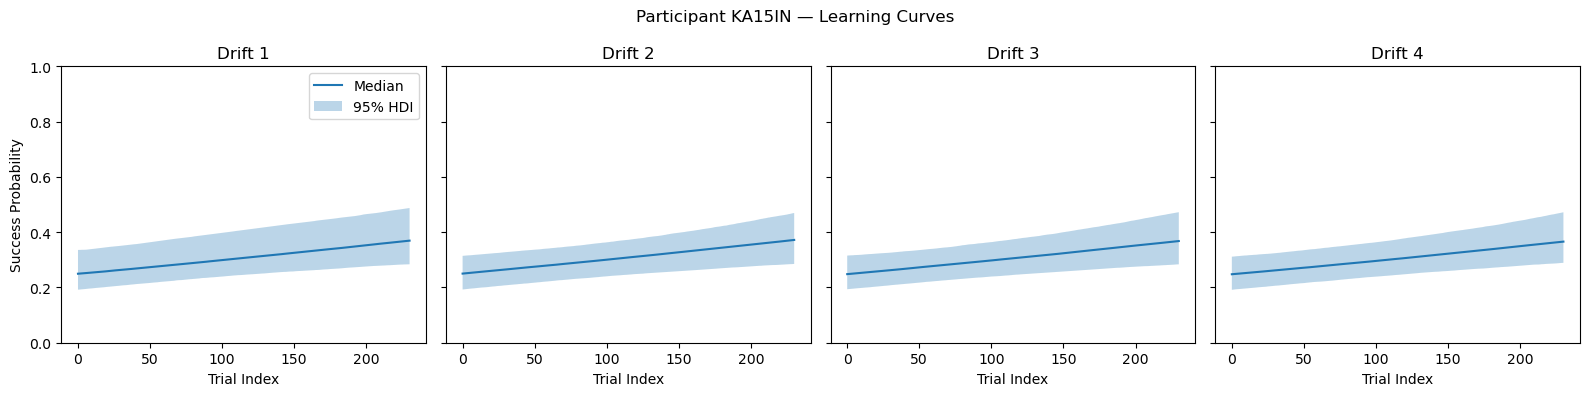

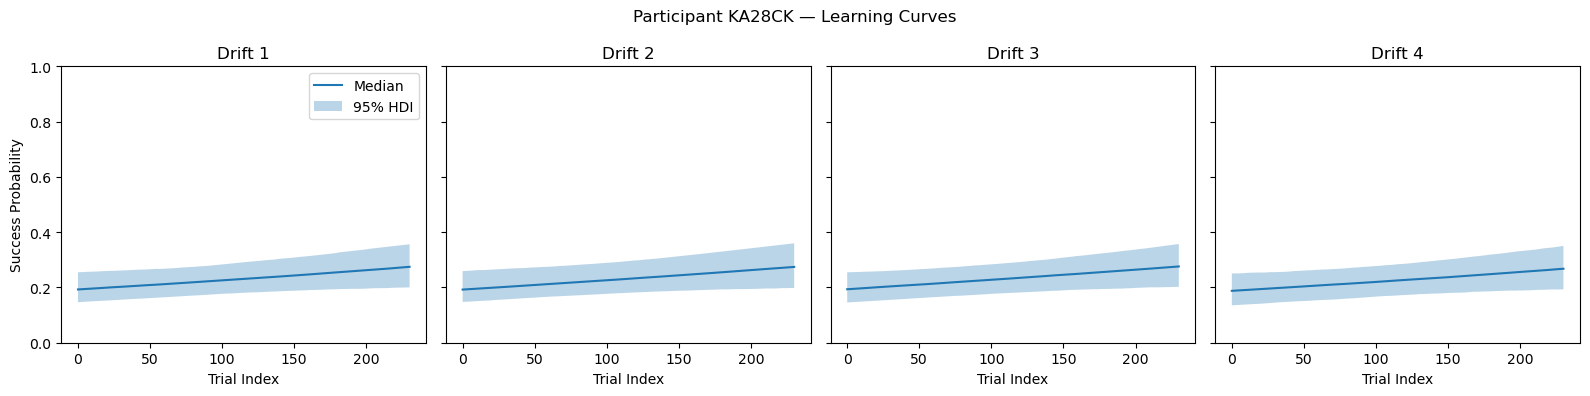

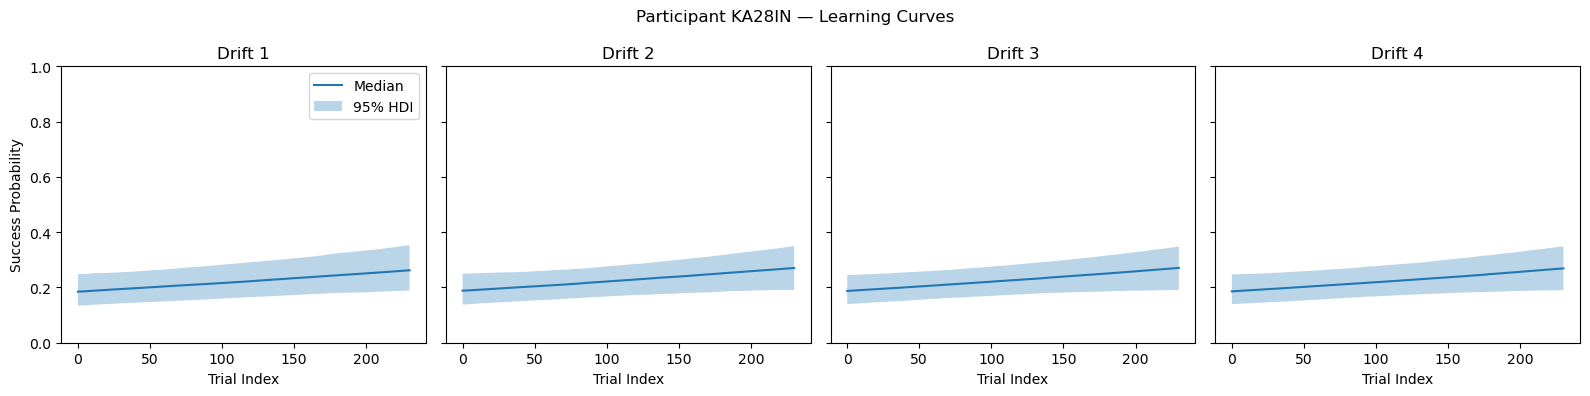

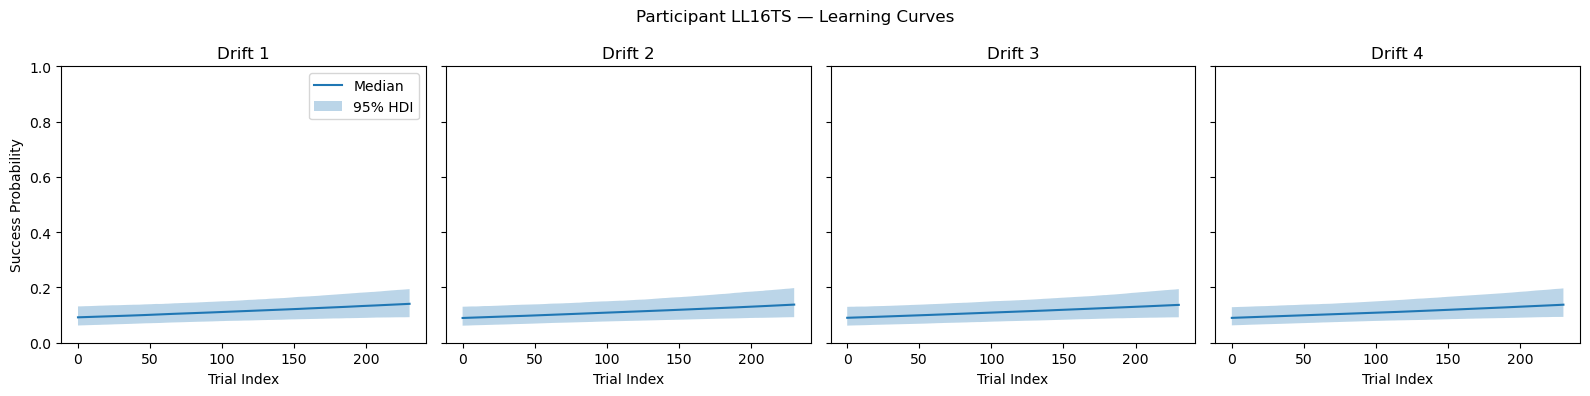

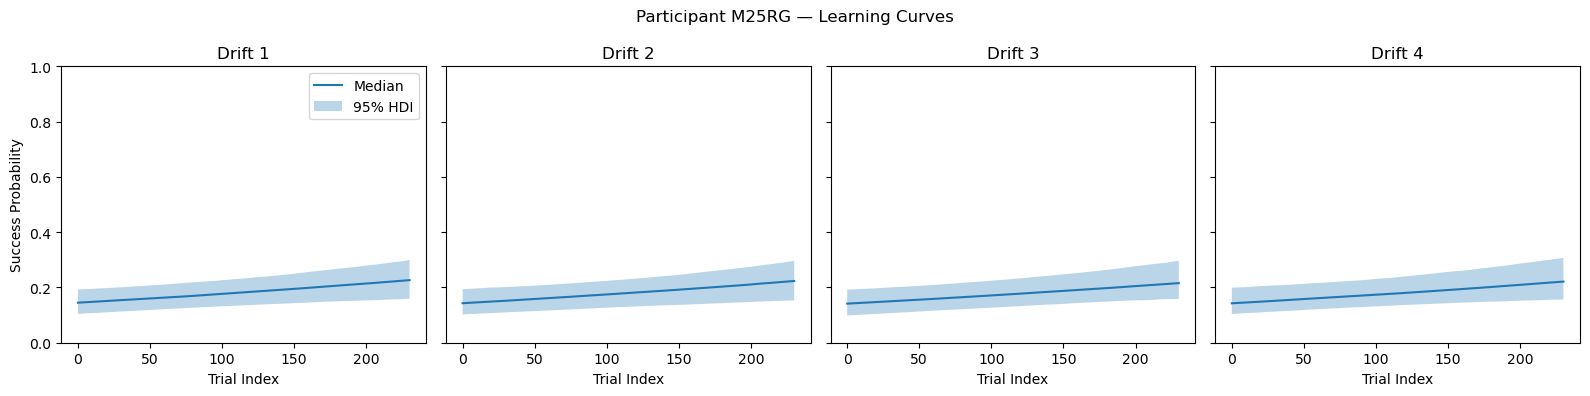

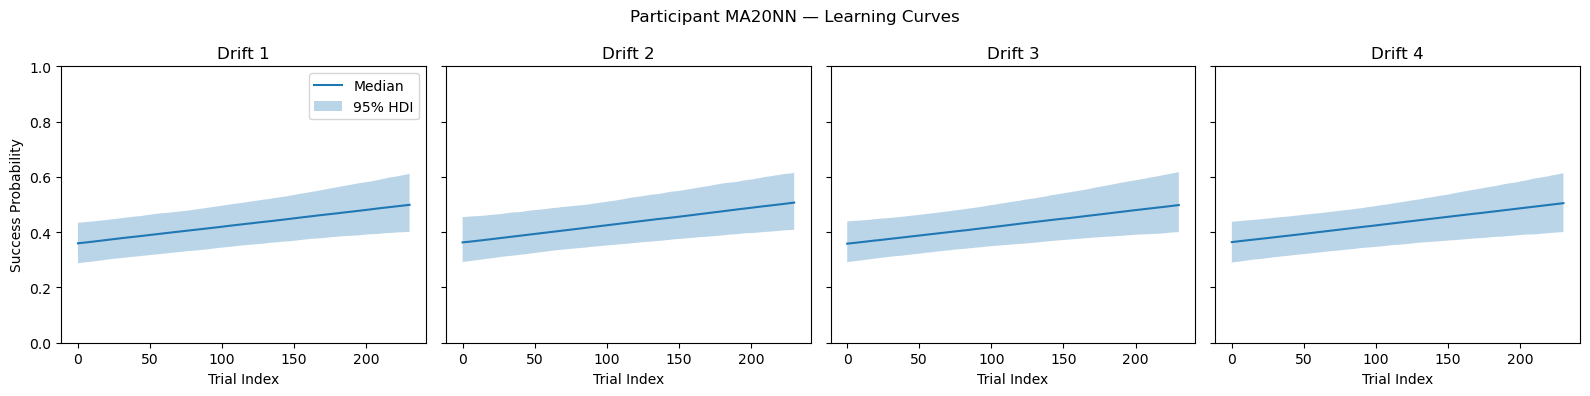

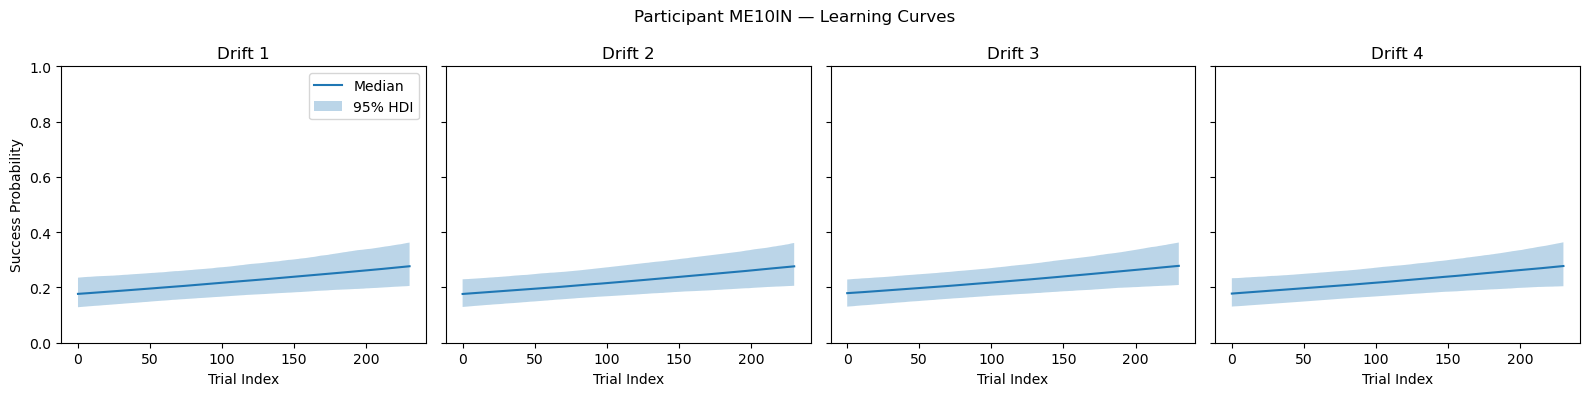

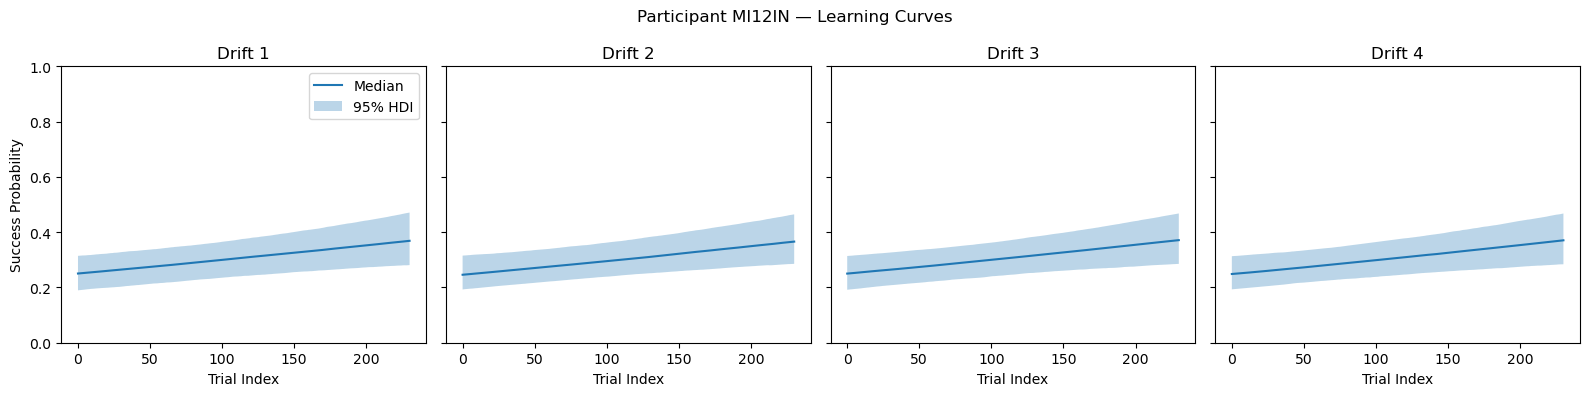

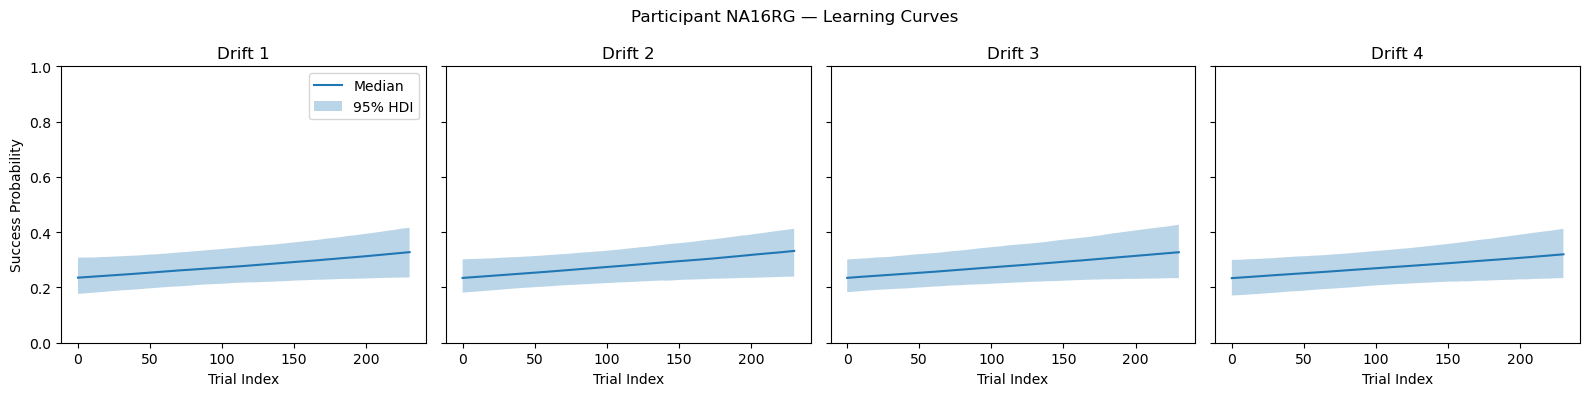

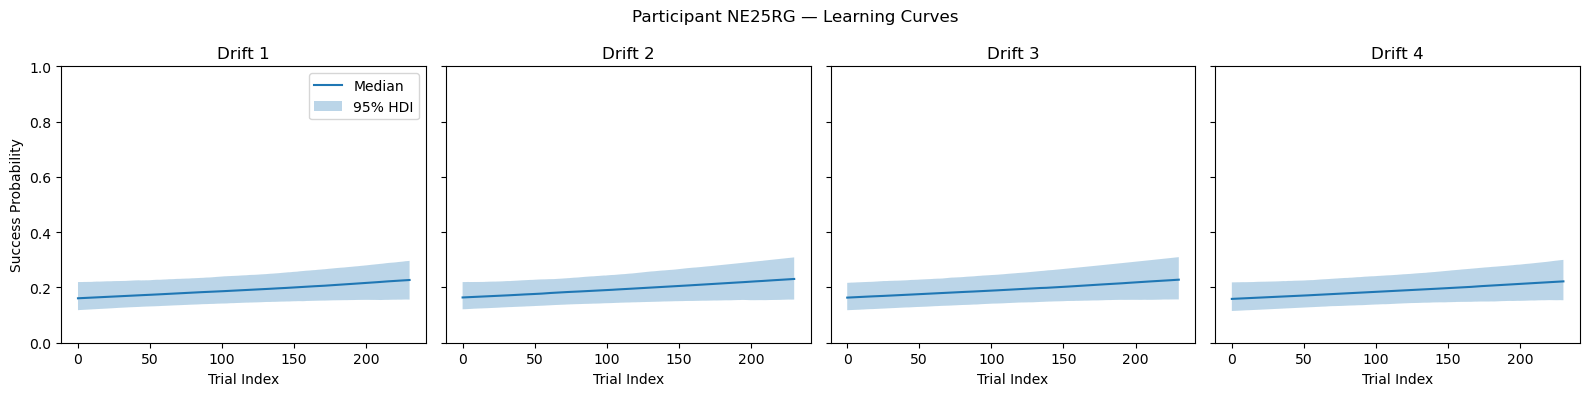

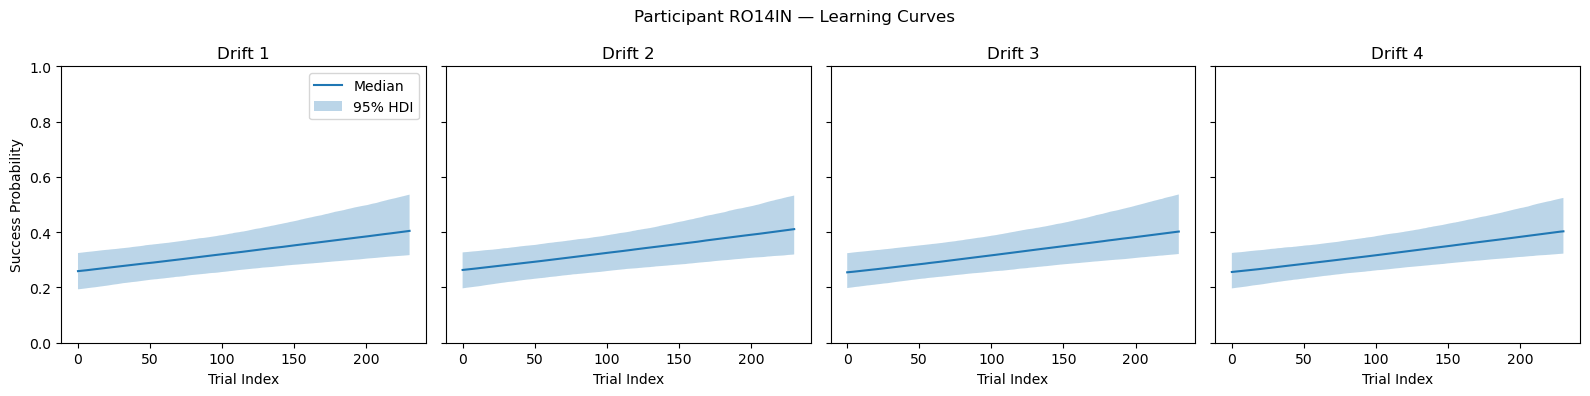

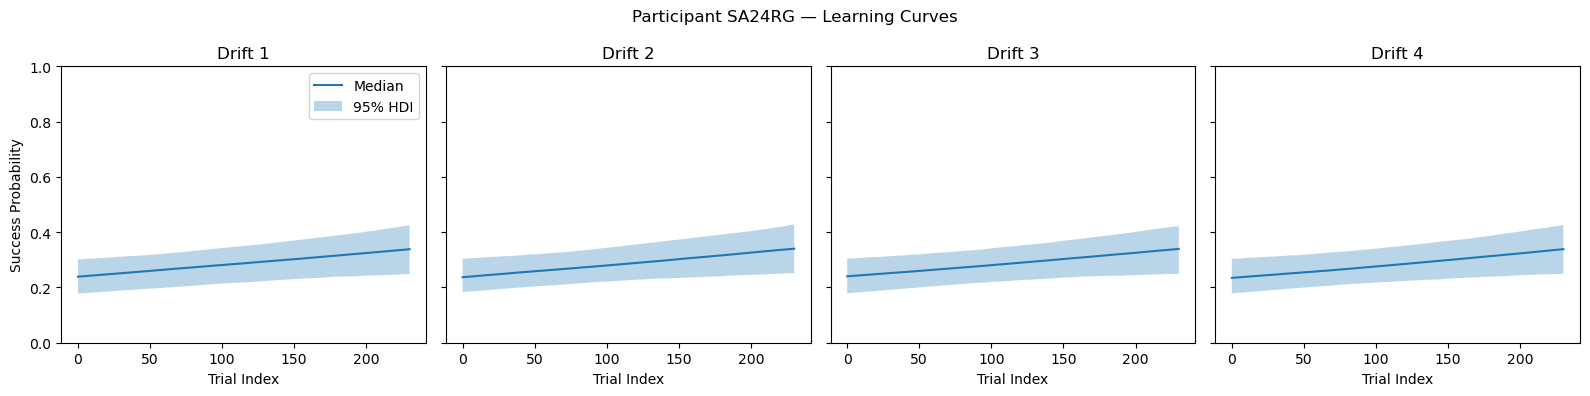

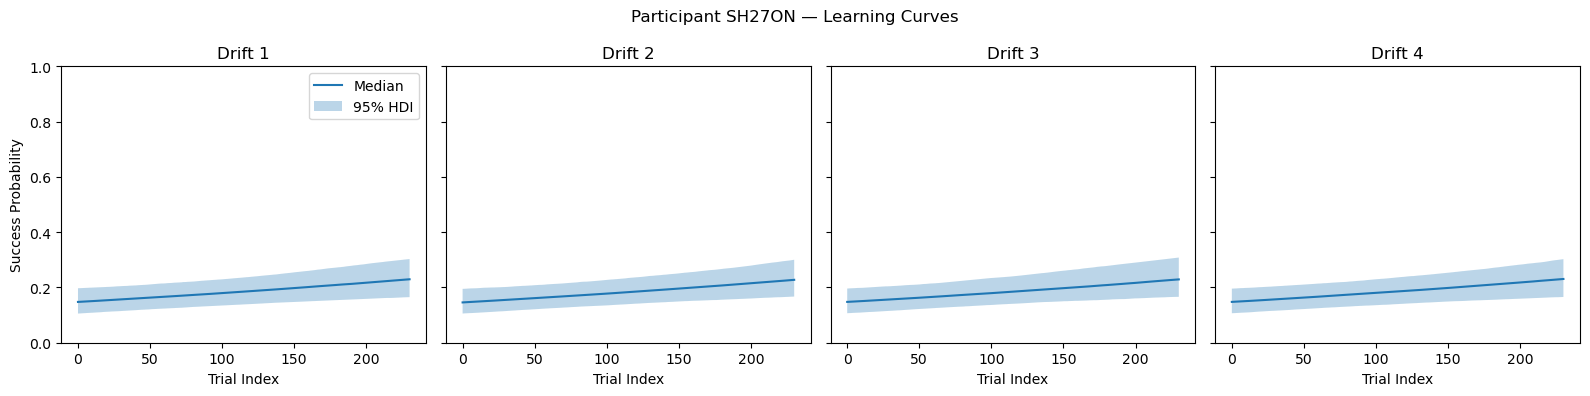

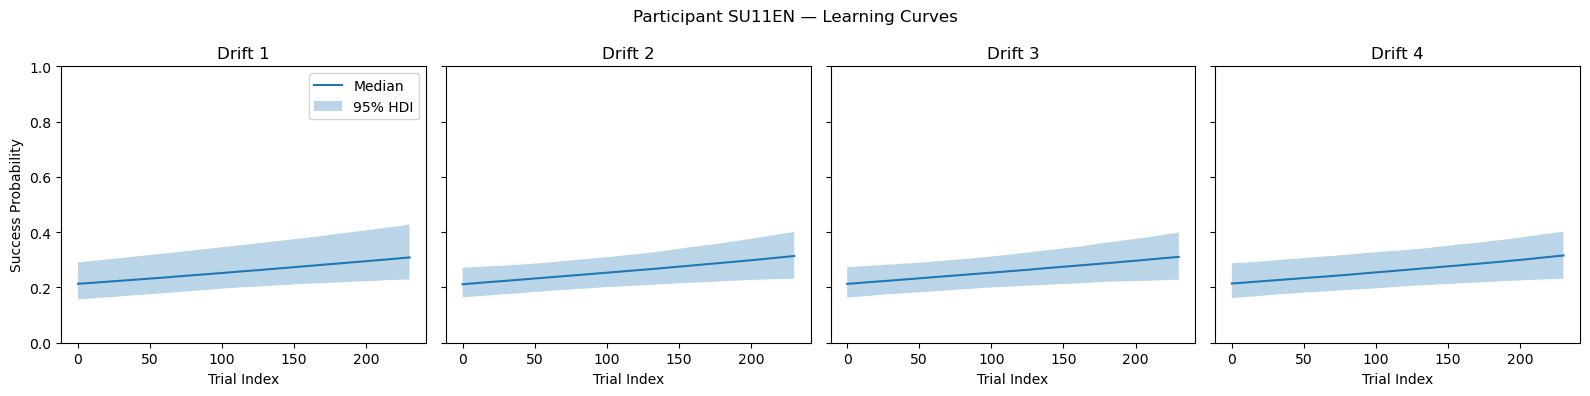

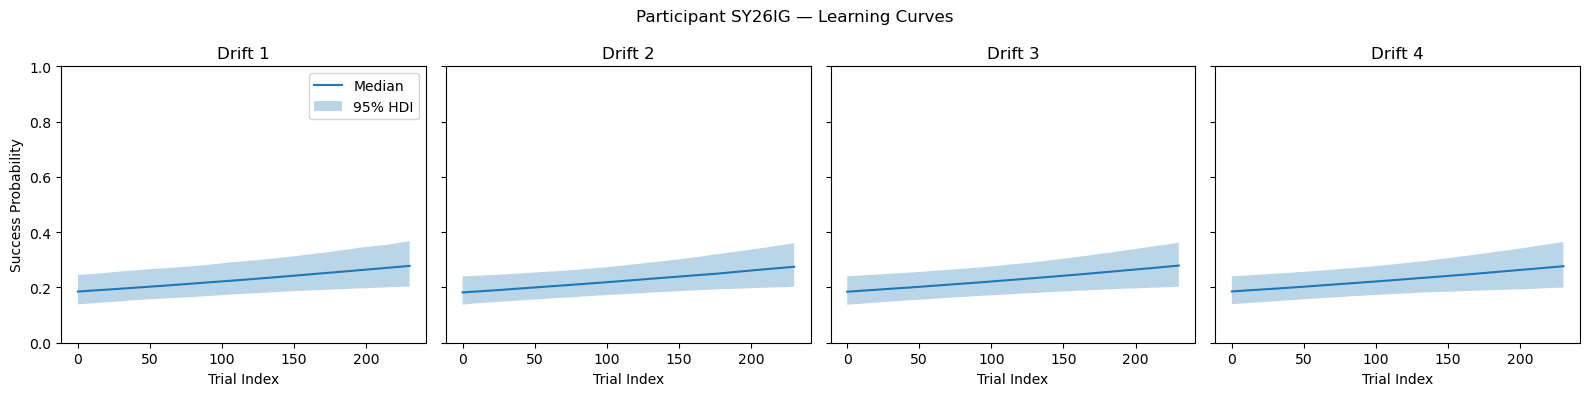

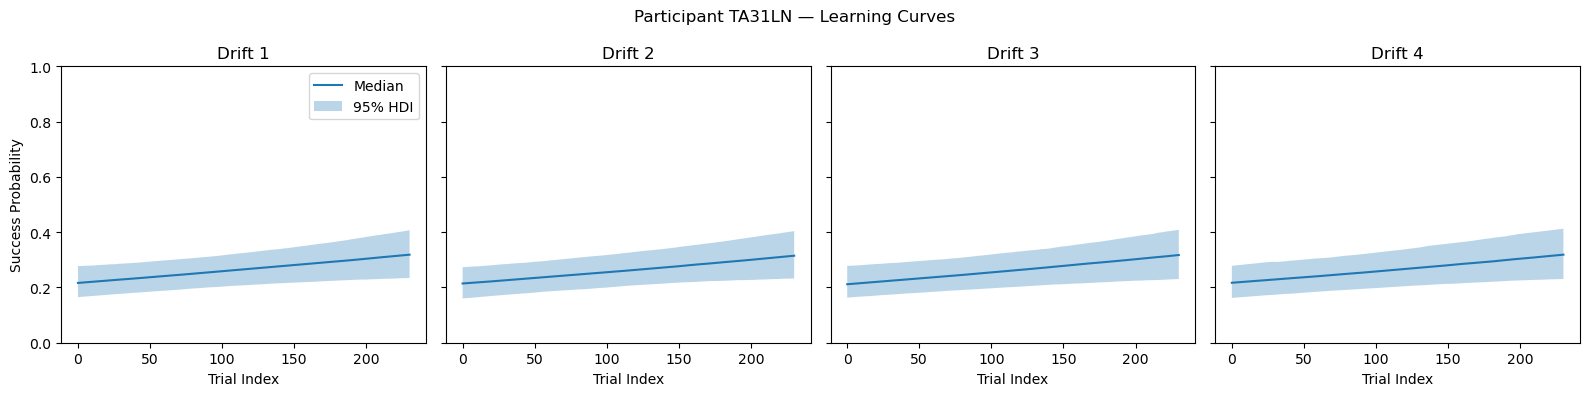

In [163]:
# say trace contains your posterior samples, and you modeled α and β like:
# α[id, drift_id], β[id, drift_id]

unique_ids = sorted(model_df['id'].unique())
id_to_index = {pid: idx for idx, pid in enumerate(unique_ids)}

from scipy.special import expit  # sigmoid

for pid in unique_ids:
    fig, axs = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
    fig.suptitle(f"Participant {pid} — Learning Curves")

    pid_idx = id_to_index[pid]

    for drift in range(1, 5):  # drift_id from 1 to 4
        ax = axs[drift - 1]

        α_samples = trace['alpha'][:, pid_idx, drift - 1]
        β_samples = trace['beta'][:, pid_idx, drift - 1]

        # predictive curve over trials
        x_vals = np.arange(0, model_df['trial_index'].max() + 1)
        probs = expit(np.outer(β_samples, x_vals) + α_samples[:, None])  # shape: (samples, x_vals)

        # compute 95% HDI
        lower = np.percentile(probs, 2.5, axis=0)
        median = np.percentile(probs, 50, axis=0)
        upper = np.percentile(probs, 97.5, axis=0)

        ax.plot(x_vals, median, label='Median')
        ax.fill_between(x_vals, lower, upper, alpha=0.3, label='95% HDI')
        ax.set_title(f"Drift {drift}")
        ax.set_xlabel("Trial Index")
        ax.set_ylim(0, 1)

    axs[0].set_ylabel("Success Probability")
    axs[0].legend()
    plt.tight_layout()
    plt.show()



### Per trial success prob

Let's standardize exp_trial (trial_index) around 0, so the scale is the same for every participant. Otherwise, we have participants starting at 0 and going to 150, and other going to 175...

In [196]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_trial = trial_level_df['trial_index'].values
x_trial_scaled = scaler.fit_transform(x_trial.reshape(-1, 1)).flatten()

In [199]:
trial_level_df = trial_level_df.groupby(['id', 'exp_trial'], as_index=False).agg({
    'success_count': 'sum'})

# add a trial index if you want (e.g., zero-based trial number per participant)
trial_level_df['trial_index'] = trial_level_df.groupby('id').cumcount()

In [201]:
import pymc3 as pm
import theano.tensor as tt


# unique participant IDs
trial_level_df['id_code'] = trial_level_df['id'].astype('category').cat.codes
id_idx = trial_level_df['id_code'].values
n_participants = trial_level_df['id_code'].nunique()

# scale trial index
x_trial = trial_level_df['trial_index'].values
x_scaled = (x_trial - x_trial.mean()) / x_trial.std()

# outcome: successes out of 4
successes = trial_level_df['success_count'].values


with pm.Model() as hierarchical_model:
    # hyperpriors (group-level)
    mu_alpha = pm.Normal('mu_alpha', mu=0, sigma=2)
    mu_beta = pm.Normal('mu_beta', mu=0, sigma=2)
    sigma_alpha = pm.HalfNormal('sigma_alpha', sigma=1)
    sigma_beta = pm.HalfNormal('sigma_beta', sigma=1)

    # participant-level intercepts and slopes
    alpha = pm.Normal('alpha', mu=mu_alpha, sigma=sigma_alpha, shape=n_participants)
    beta = pm.Normal('beta', mu=mu_beta, sigma=sigma_beta, shape=n_participants)

    # compute logit per data point
    logits = alpha[id_idx] + beta[id_idx] * x_scaled # x_trial
    p = pm.Deterministic('p', tt.clip(pm.math.sigmoid(logits), 1e-6, 1 - 1e-6))

    # Likelihood
    obs = pm.Binomial('obs', n=4, p=p, observed=successes)

    # sample from posterior
    trace = pm.sample(1000, tune=1000, target_accept=0.9, cores=2, random_seed=36)


/var/folders/z1/crk0j_p52yq850yynjpq93wm0000gn/T/ipykernel_17032/3402457903.py:37: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  trace = pm.sample(1000, tune=1000, target_accept=0.9, cores=2, random_seed=36)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta, alpha, sigma_beta, sigma_alpha, mu_beta, mu_alpha]


/Users/heinrich/anaconda3/envs/datascience/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/heinrich/anaconda3/envs/datascience/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 34 seconds.


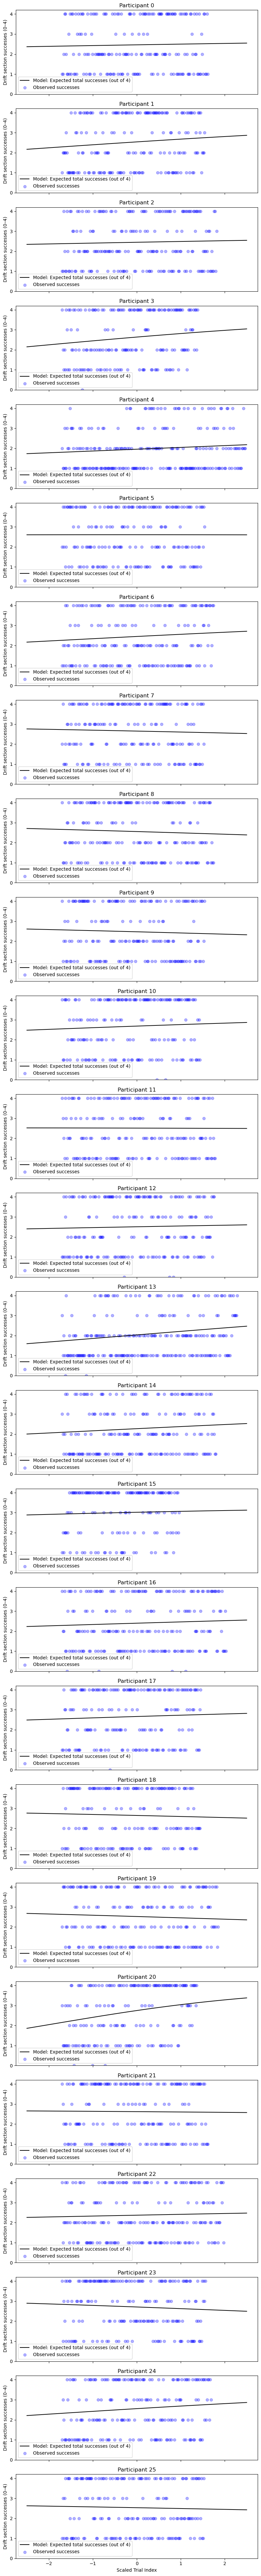

In [209]:
# z-score standardization of actual data trial index
scaler = StandardScaler()
trial_level_df['trial_index_scaled'] = scaler.fit_transform(trial_level_df[['trial_index']])

# specific participants to plot
participant_ids = np.unique(trial_level_df['id_code'])#[:5]

fig, axs = plt.subplots(len(participant_ids), 1, figsize=(8, 3 * len(participant_ids)), sharex=True)

for i, pid in enumerate(participant_ids):
    ax = axs[i]

    # --- get model predictions ---
    alpha_samples = trace['alpha'][:, pid]
    beta_samples = trace['beta'][:, pid]

    x_vals = np.linspace(-2.5, 2.5, 100)
    p_samples = 1 / (1 + np.exp(-(alpha_samples[:, None] + beta_samples[:, None] * x_vals[None, :])))
    mean_p = p_samples.mean(axis=0)

    ax.plot(x_vals, mean_p * 4, label='Model: Expected total successes (out of 4)', color='black')

    # --- real data points ---
    subset = trial_level_df[trial_level_df['id_code'] == pid]
    ax.scatter(
        subset['trial_index_scaled'],
        subset['success_count'],
        alpha=0.3,
        color='blue',
        label='Observed successes',
    )

    ax.set_title(f'Participant {pid}')
    ax.set_ylabel("Drift section successes (0–4)")
    ax.set_ylim(0, 4.2)
    ax.set_yticks([0, 1, 2, 3, 4])
    ax.legend()

axs[-1].set_xlabel("Scaled Trial Index")
plt.tight_layout()
plt.show()



In [203]:
trial_level_df['success_count'].mean()

2.5040098704503393

## Center bias outside of drift sections

Let's transform the data first with all the necessary columns while collapsing over individual trials (per-trial center deviation). We will also cut off the start of each trial, where participants "fly in", and of course drop the drift sections. 

In [214]:
records = []

grouped = corrected_df.groupby(['id', 'exp_trial'])

for (pid, trial), group in grouped:
    group = group.sort_values('y')  # vertical position = time proxy

    # find where wall_tile[:,1] starts changing — signals control given to participants
    wall_column = np.stack(group['wall_tile'].values)
    wall_second_col = wall_column[:, 1]
    diffs = np.diff(wall_second_col)
    
    # find the first index where wall_tile[1] changes (player takes control)
    control_start_idx = np.argmax(diffs != 0) + 1 if np.any(diffs != 0) else 0
    
    group_control = group.iloc[control_start_idx:].copy()
    
    if group_control.empty:
        continue  # skip if no usable data

    # get start-relative_x after control is given
    start_relative_x = group_control.iloc[0]['relative_x']
    
    # keep only non-drift samples (current_drift == 0)
    no_drift = group_control[group_control['current_drift'] == 0]

    # compute mean absolute deviation from starting position
    deviation = np.mean(np.abs(no_drift['relative_x'] - start_relative_x))

    records.append({
        'id': pid,
        'exp_trial': trial,
        'deviation_from_start': deviation
    })

center_deviation_df = pd.DataFrame(records)

# add trial index for modeling
center_deviation_df['trial_index'] = center_deviation_df.groupby('id').cumcount()


In [215]:
from sklearn.preprocessing import StandardScaler

# participant IDs
center_deviation_df['id_code'] = center_deviation_df['id'].astype('category').cat.codes
id_idx = center_deviation_df['id_code'].values
n_participants = center_deviation_df['id_code'].nunique()

# scale trial index
x_trial = center_deviation_df['trial_index'].values
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_trial.reshape(-1, 1)).flatten()

# outcome: deviation from center
y_deviation = center_deviation_df['deviation_from_start'].values

In [216]:
with pm.Model() as center_bias_model:
    # hyperpriors for group-level effects
    mu_alpha = pm.Normal('mu_alpha', mu=0, sigma=1)
    mu_beta = pm.Normal('mu_beta', mu=0, sigma=1)
    sigma_alpha = pm.HalfNormal('sigma_alpha', sigma=1)
    sigma_beta = pm.HalfNormal('sigma_beta', sigma=1)

    # participant-level effects
    alpha = pm.Normal('alpha', mu=mu_alpha, sigma=sigma_alpha, shape=n_participants)
    beta = pm.Normal('beta', mu=mu_beta, sigma=sigma_beta, shape=n_participants)

    # linear model
    mu = alpha[id_idx] + beta[id_idx] * x_scaled

    # observation noise
    sigma = pm.HalfNormal('sigma', sigma=1)

    # Likelihood
    obs = pm.Normal('obs', mu=mu, sigma=sigma, observed=y_deviation)

    # sample from posterior
    trace_center = pm.sample(1000, tune=1000, target_accept=0.9, cores=2, random_seed=36)


/var/folders/z1/crk0j_p52yq850yynjpq93wm0000gn/T/ipykernel_17032/722390386.py:24: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  trace_center = pm.sample(1000, tune=1000, target_accept=0.9, cores=2, random_seed=42)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [sigma, beta, alpha, sigma_beta, sigma_alpha, mu_beta, mu_alpha]


/Users/heinrich/anaconda3/envs/datascience/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/heinrich/anaconda3/envs/datascience/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 43 seconds.


In [228]:
center_deviation_df.columns

Index(['id', 'exp_trial', 'deviation_from_start', 'trial_index', 'id_code'], dtype='object')

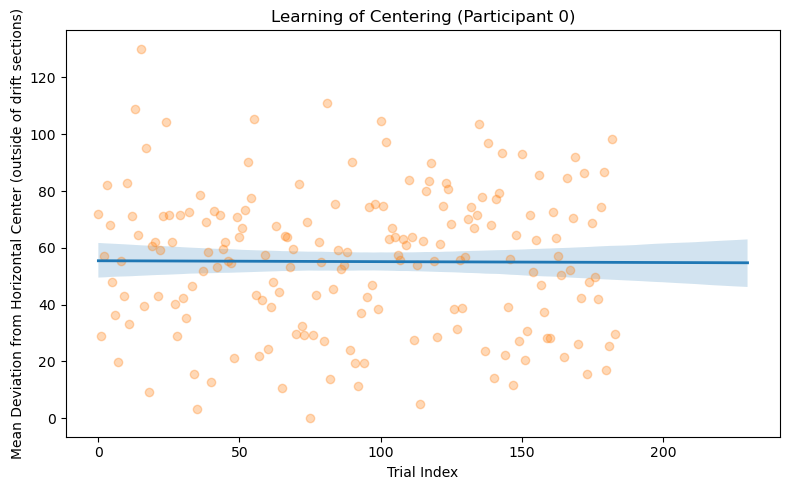

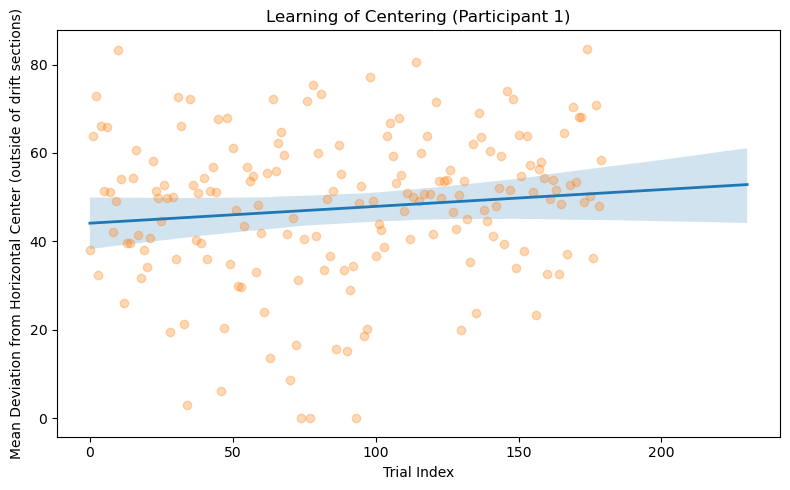

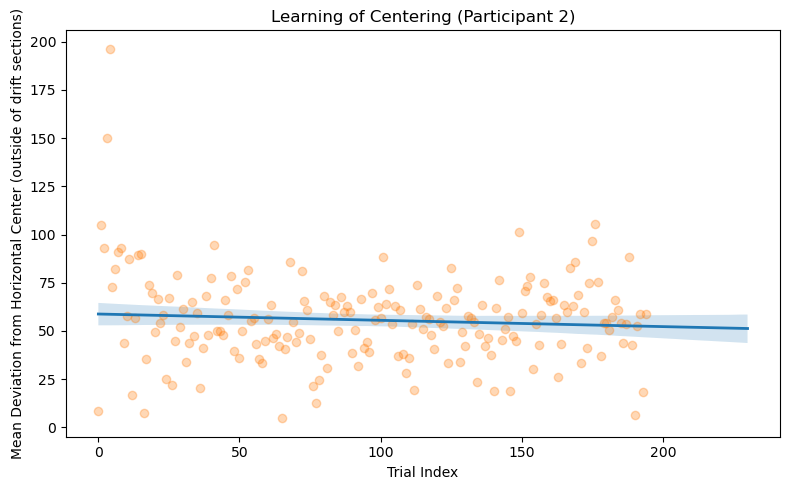

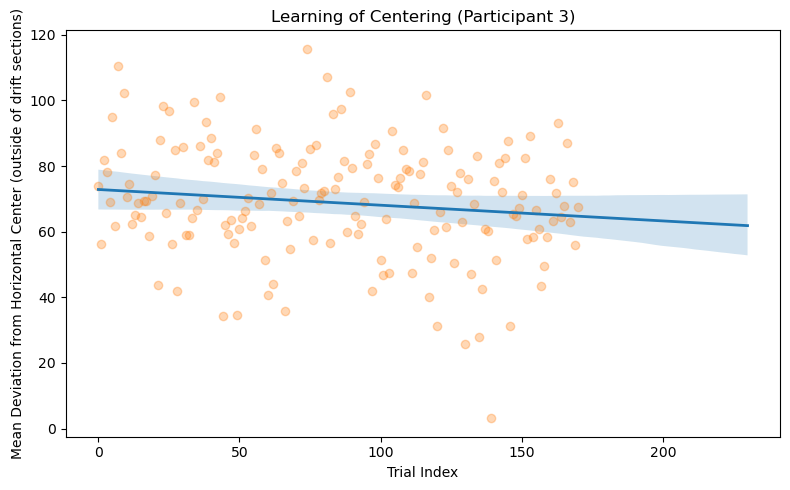

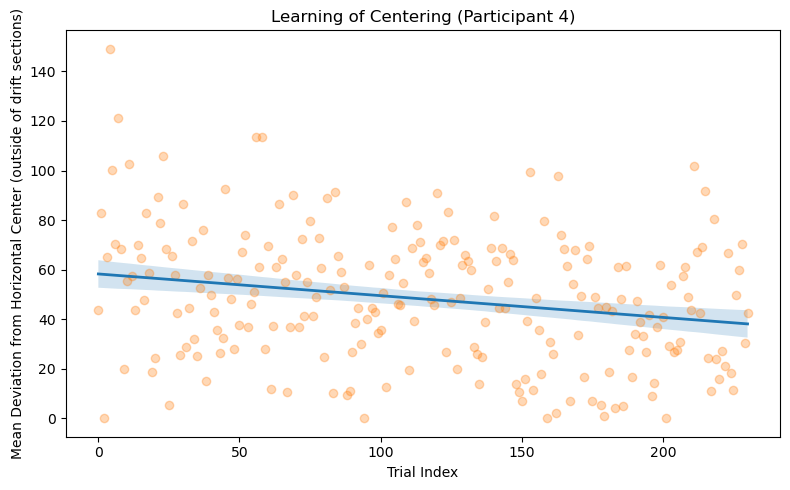

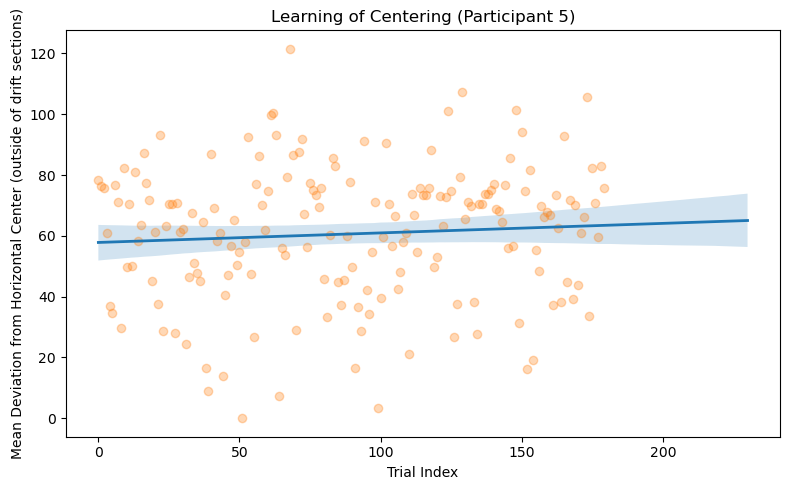

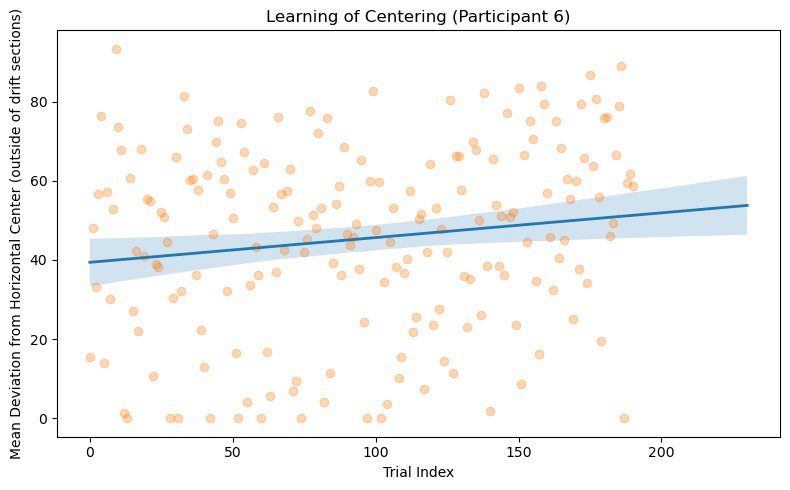

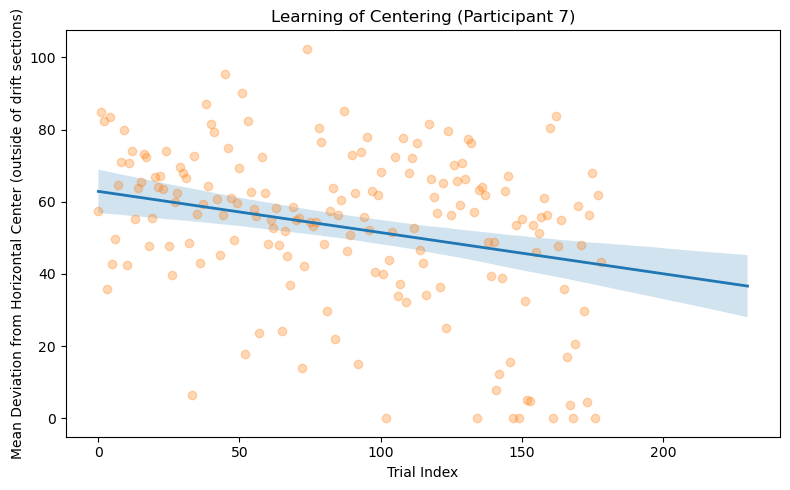

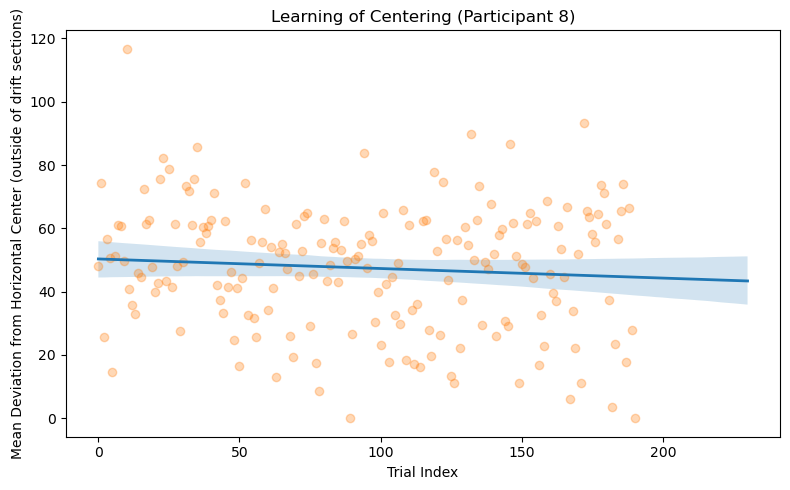

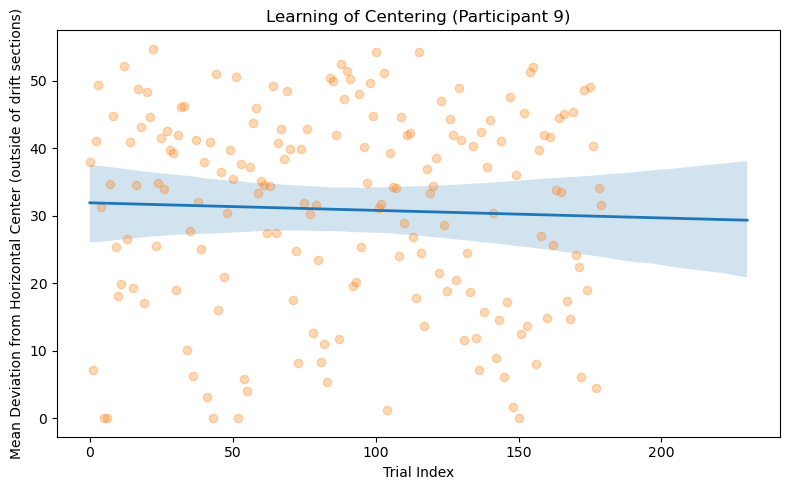

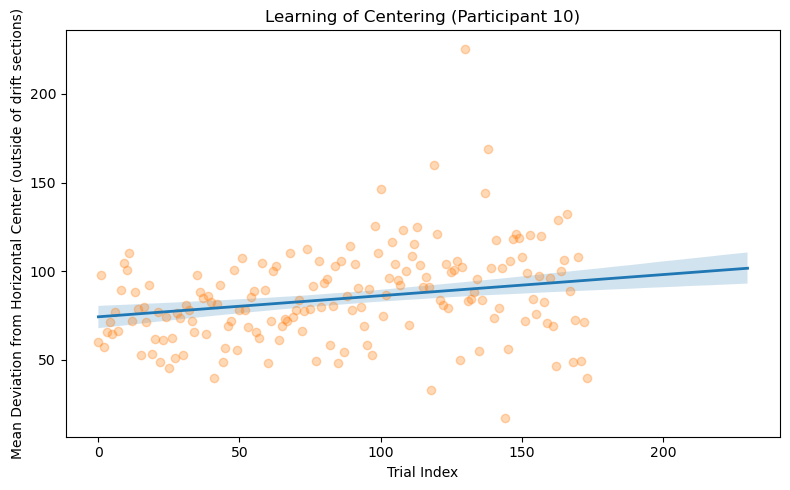

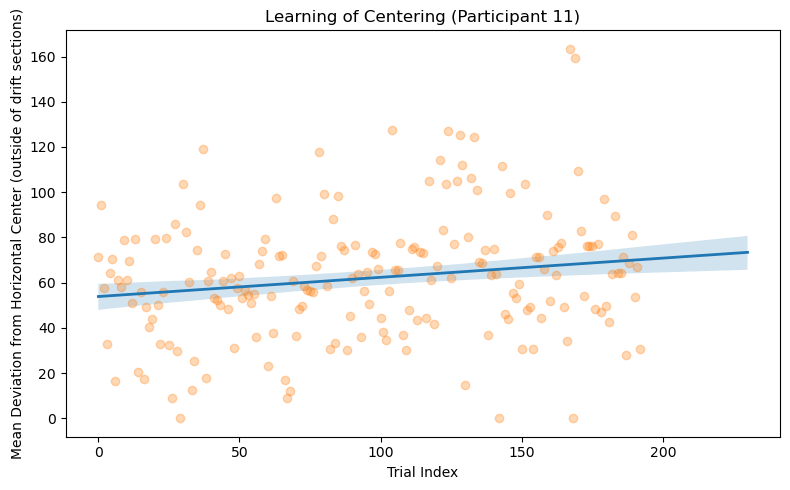

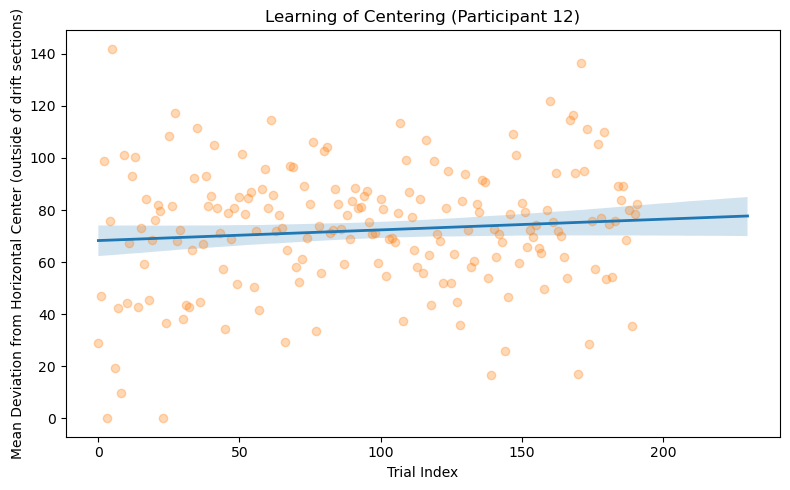

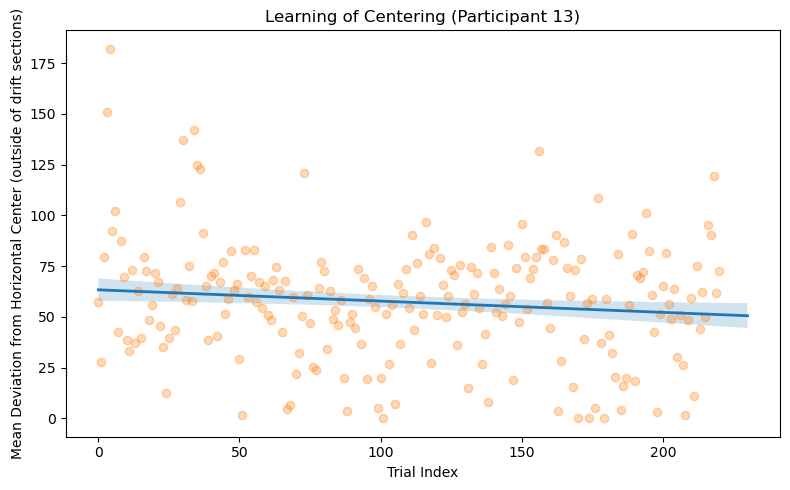

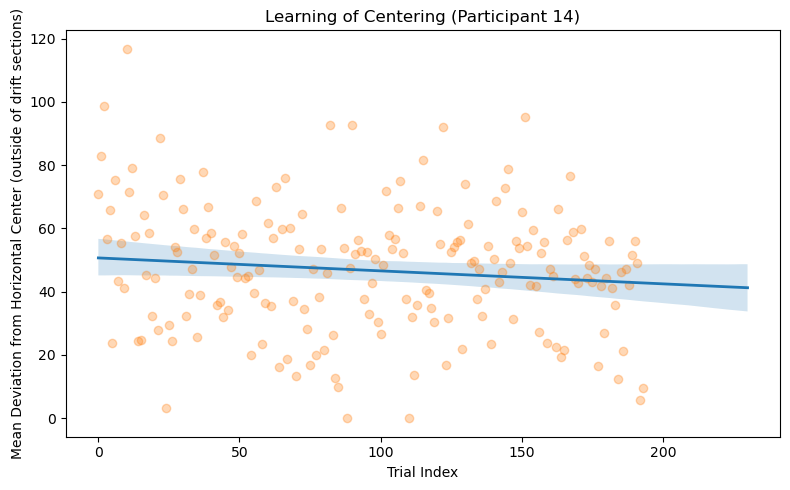

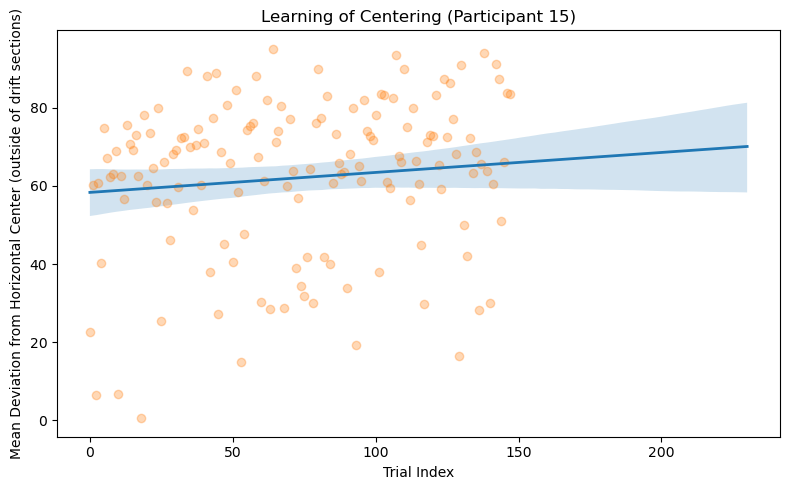

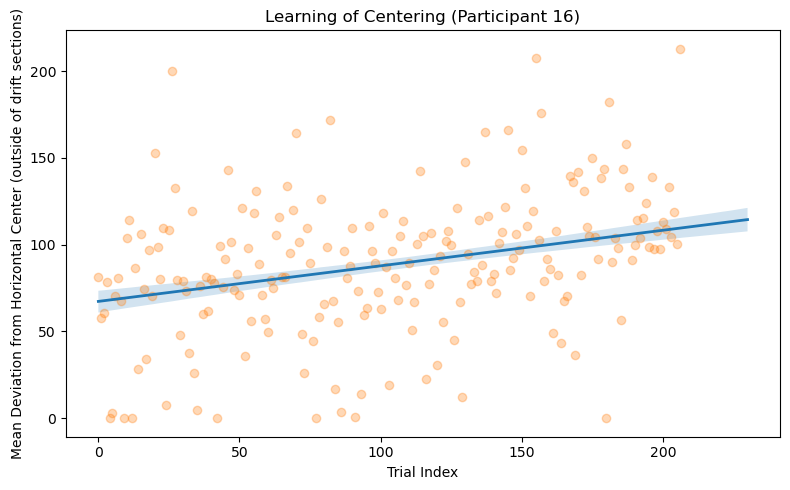

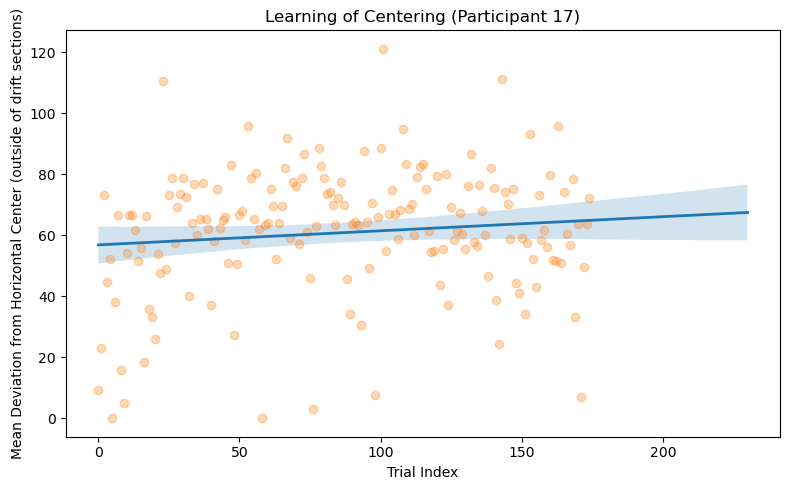

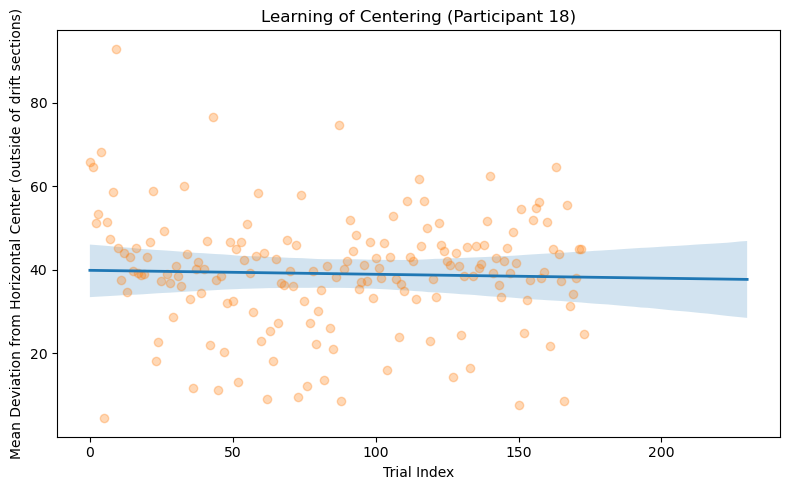

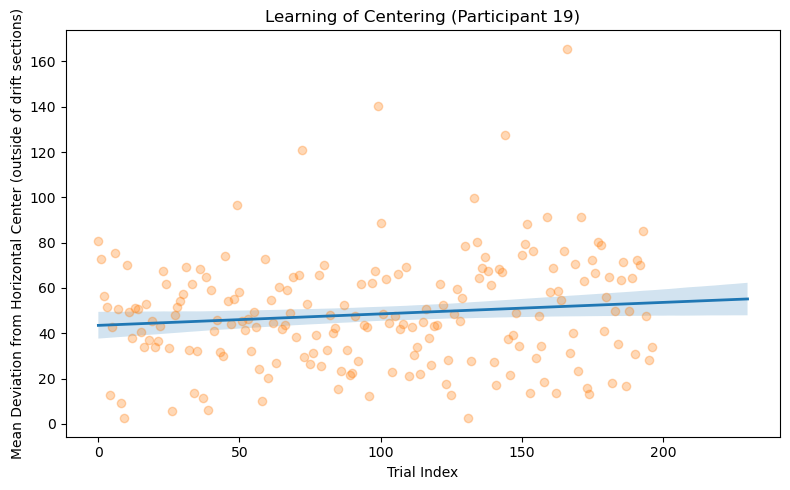

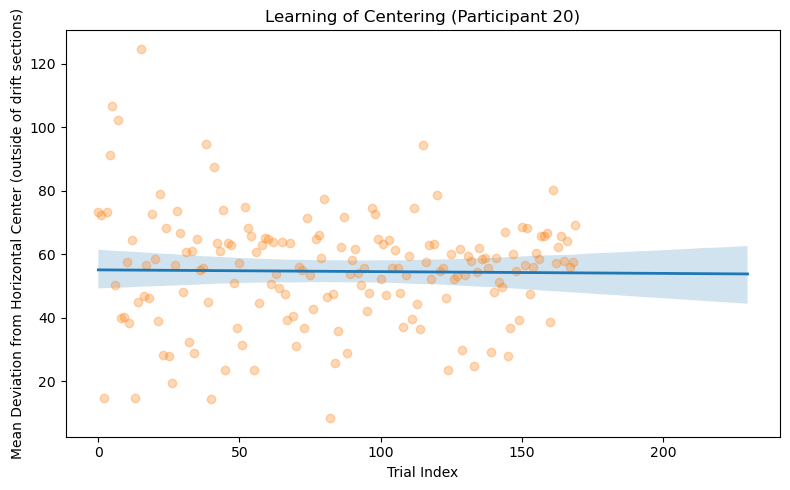

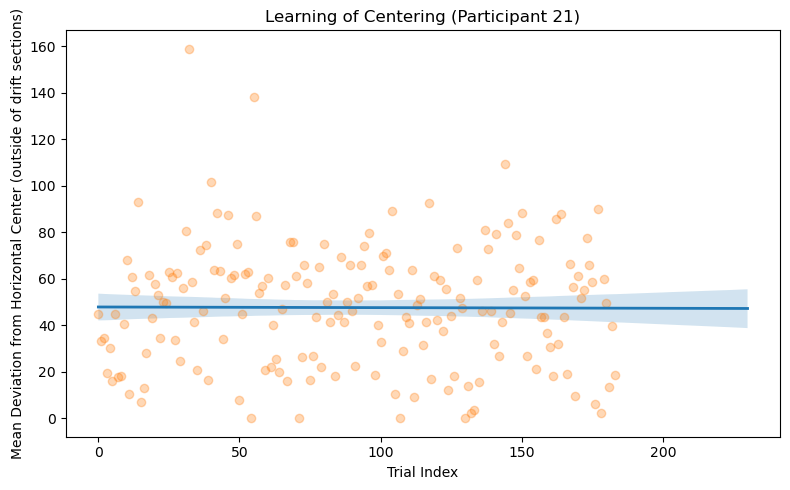

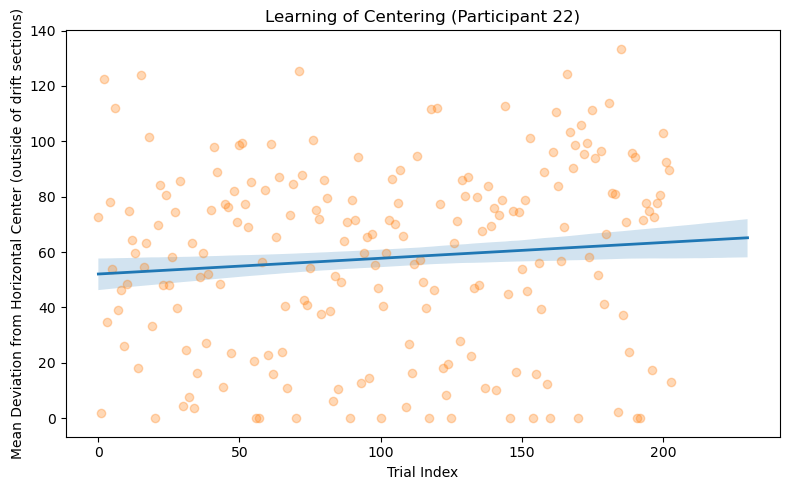

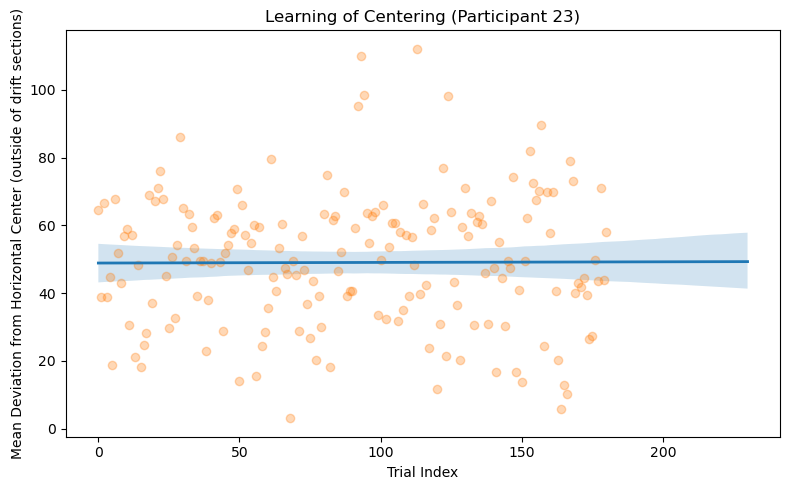

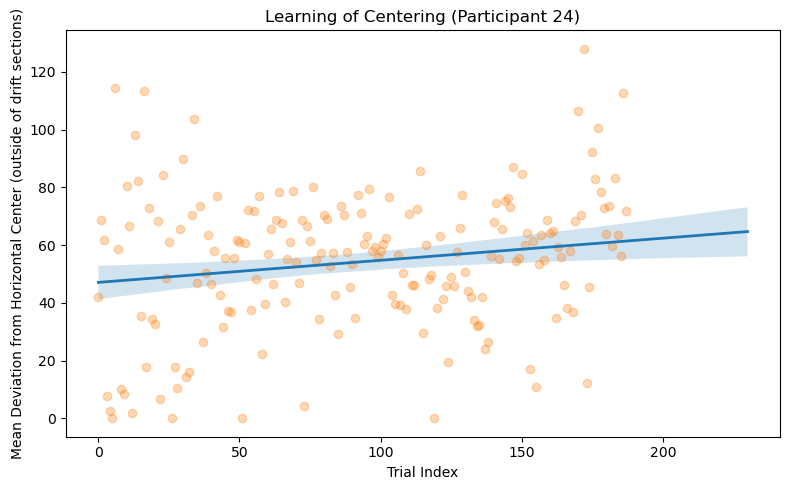

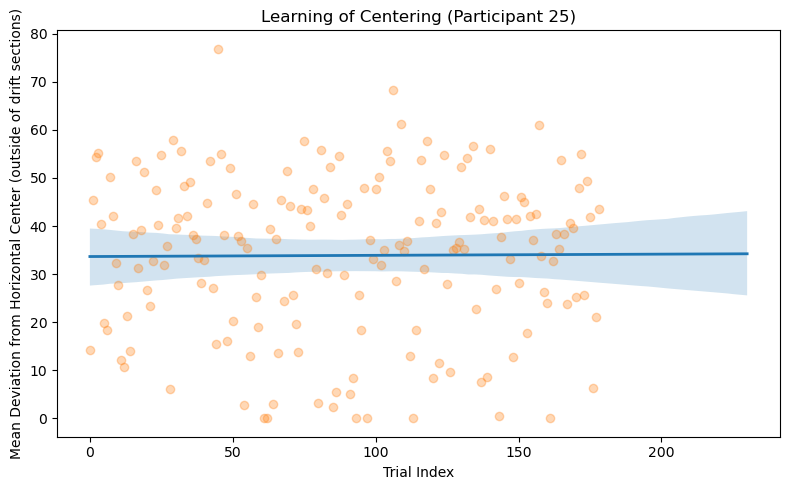

In [234]:
x_vals = np.linspace(center_deviation_df['trial_index'].min(),
                     center_deviation_df['trial_index'].max(), 100)
x_scaled_vals = (x_vals - center_deviation_df['trial_index'].mean()) / center_deviation_df['trial_index'].std()

participant_ids = center_deviation_df['id_code'].unique()#[:5]

# number of draws and participants
alpha_samples = trace_center['alpha']  # shape: (n_draws, n_participants)
beta_samples = trace_center['beta']    # same shape

for pid in participant_ids:
    fig, ax = plt.subplots(figsize=(8, 5))
    
    alpha_pid = alpha_samples[:, pid]
    beta_pid = beta_samples[:, pid]

    preds = np.outer(beta_pid, x_scaled_vals) + alpha_pid[:, None]

    mean_pred = preds.mean(axis=0)
    lower = np.percentile(preds, 2.5, axis=0)
    upper = np.percentile(preds, 97.5, axis=0)

    ax.plot(x_vals, mean_pred, linewidth=2)
    ax.fill_between(x_vals, lower, upper, alpha=0.2)

    # actual data
    subset = center_deviation_df[center_deviation_df['id_code'] == pid]
    ax.scatter(subset['trial_index'], subset['deviation_from_start'], alpha=0.3)

    ax.set_title(f"Learning of Centering (Participant {pid})")
    ax.set_xlabel("Trial Index")
    ax.set_ylabel("Mean Deviation from Horizontal Center (outside of drift sections)")
    plt.tight_layout()
    plt.show()


# Plotting path kernel density estimates

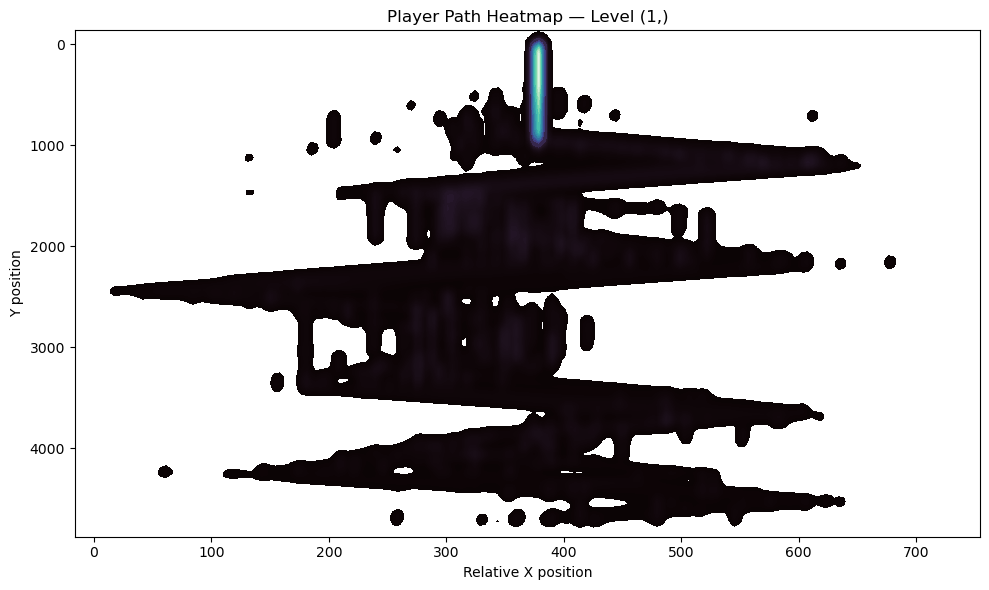

In [15]:
grouped = corrected_df.groupby(['level'])

for level, group in grouped:
    plt.figure(figsize=(10, 6))

    # 2D density (KDE) of relative_x vs y
    sns.kdeplot(
        data=group,
        x='relative_x',
        y='y',
        fill=True,
        cmap='mako',  # 'viridis', 'rocket'
        bw_adjust=0.2,  # controls smoothing
        thresh=0.05,    # cut low density noise
        levels=100
    )

    plt.title(f"Player Path Heatmap — Level {level}")
    plt.xlabel("Relative X position")
    plt.ylabel("Y position")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    break


These plots above look like ink bleedings. Nice! Let's call them "**Ink Blots**" or "**Ink Trails**" (simple, memorable, metaphorical—could work well in both scientific writing and presentations) - someone drew the line with ink and it bled...

In [14]:
drift_cols = ['y_start', 'y_end', 'direction', 'visibility', 'fake']

drift_1 = pd.read_csv("../../../../Volumes/KMODyS_1/Experiment4/logs/drift_ranges_1.csv", names=drift_cols)
drift_1

,y_start,y_end,direction,visibility,fake
0,216,231,-1,True,False
1,135,150,1,True,False
2,272,287,-1,True,False
3,69,84,1,True,False


In [68]:
sim_dat = pd.read_csv("simulation_output_1_00.csv")

sim_dat["player_pos"] = sim_dat.player_pos.apply(lambda x: literal_eval(x))
player_positions = sim_dat["player_pos"]

x_vals = [pos[0] if isinstance(pos, (list, tuple)) and len(pos) > 0 else np.nan for pos in player_positions]

# drop missing values and keep only the first N values
x_vals = [x for x in x_vals if pd.notna(x)]
sim_dat['x'] = x_vals

# relative_x
sim_dat["last_walls_tile"] = sim_dat.last_walls_tile.apply(lambda x: literal_eval(x))
level_width = 40*scaling  # 40 as fixed variable when generating the levels
sim_dat['relative_x'] = sim_dat.apply(lambda row: level_width - (row['last_walls_tile'][0] - row['x']), axis=1)

# match to y = 0, 5, 10, ... (pixel values), same length as x_vals
y_vals = list(range(0, len(x_vals) * 5, 5))

sim_dat['y'] = y_vals

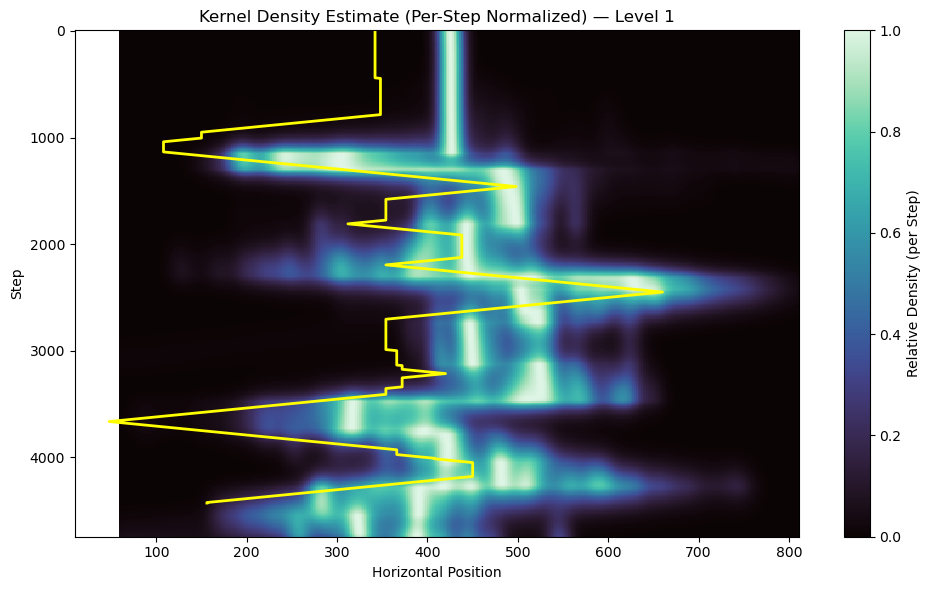

In [69]:
from scipy.stats import gaussian_kde

grouped = corrected_df.groupby('level')

drift_cols = ['y_start', 'y_end', 'direction', 'visibility', 'fake']

for level, group in grouped:
    # fetch drift ranges
    #drift_ranges = pd.read_csv(f"../../../../Volumes/KMODyS_1/Experiment4/logs/drift_ranges_{level}.csv", names=drift_cols)
    #drift_ranges = drift_ranges.sort_values(by=['y_start'])
    
    x = group['relative_x'].values
    y = group['y'].values

    # grid (binning)
    x_bins = np.linspace(x.min(), x.max(), 400)
    y_bins = np.linspace(y.min(), y.max(), 400)
    X, Y = np.meshgrid(x_bins, y_bins)
    positions = np.vstack([X.ravel(), Y.ravel()])

    # compute KDE
    kde = gaussian_kde(np.vstack([x, y]), bw_method=0.1)  # controls smoothing
    Z = kde(positions).reshape(X.shape)

    # normalize by row (per y-bin)
    Z_norm = Z / Z.max(axis=1, keepdims=True)
    Z_norm = np.nan_to_num(Z_norm)
    
    # plotting
    plt.figure(figsize=(10, 6))
    plt.pcolormesh(X, Y, Z_norm, shading='auto', cmap='mako')
    plt.gca().invert_yaxis()
    
    # -drift ranges
    #drift_onsets = group[group.drift_onset > 0].y
    #values, counts = np.unique(drift_onsets, return_counts=True)
    ## there are some incosistencies with the drift ranges. We will take the for most common starting positions of drift within a level
    #top_indices = np.argsort(counts)[-4:][::-1]  
    #top_values = values[top_indices]
    
    #width = 10
    #for drift_start, (index, row) in zip(top_values, drift_ranges.iterrows()):
    #    #if row['direction'] == -1:
    #    #    x_coord = 700-width
    #    #else:
    #    #    x_coord = 0
    #    drift_bar = mpatches.Rectangle((0, drift_start), 750, 170, linewidth=1, edgecolor='none', facecolor='r', alpha=0.2)
    #    plt.gca().add_patch(drift_bar)
    #    # (row['y_end']-row['y_start'])*scaling
    
    # overlay sim_dat points
    plt.plot(sim_dat['relative_x'], sim_dat['y'], color='yellow', linewidth=2, label='simulated data')
    
    plt.colorbar(label='Relative Density (per Step)')
    plt.xlabel('Horizontal Position')
    plt.ylabel('Step')
    plt.title(f'Kernel Density Estimate (Per-Step Normalized) — Level {level}')
    plt.tight_layout()
    plt.show()

    break


1
1
-1
-1


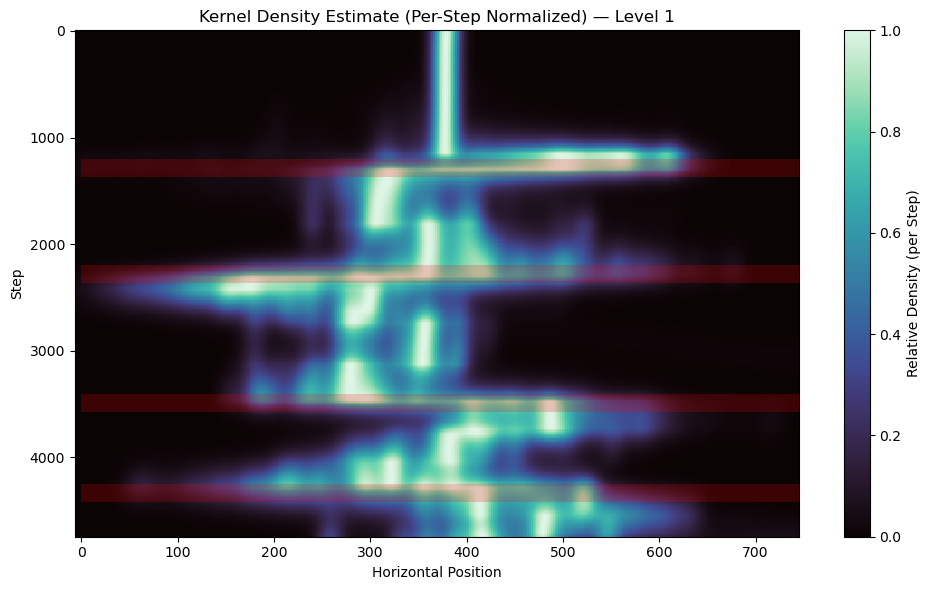

In [43]:
drift_ranges = drift_ranges.sort_values(by=['y_start'])

# plotting
plt.figure(figsize=(10, 6))
plt.pcolormesh(X, Y, Z_norm, shading='auto', cmap='mako')
plt.gca().invert_yaxis()

# -drift ranges
drift_onsets = group[group.drift_onset > 0].y
values, counts = np.unique(drift_onsets, return_counts=True)
top_indices = np.argsort(counts)[-4:][::-1]
top_values = values[top_indices]

width = 10
for drift_start, (index, row) in zip(top_values, drift_ranges.iterrows()):
    print(row.direction)
    #if row['direction'] == -1:
    #    x_coord = 700-width
    #else:
    #    x_coord = 0
    drift_bar = mpatches.Rectangle((0, drift_start), 750, 170, linewidth=1, edgecolor='none', facecolor='r', alpha=0.2)
    plt.gca().add_patch(drift_bar)

plt.colorbar(label='Relative Density (per Step)')
plt.xlabel('Horizontal Position')
plt.ylabel('Step')
plt.title(f'Kernel Density Estimate (Per-Step Normalized) — Level {level}')
plt.tight_layout()
plt.show()

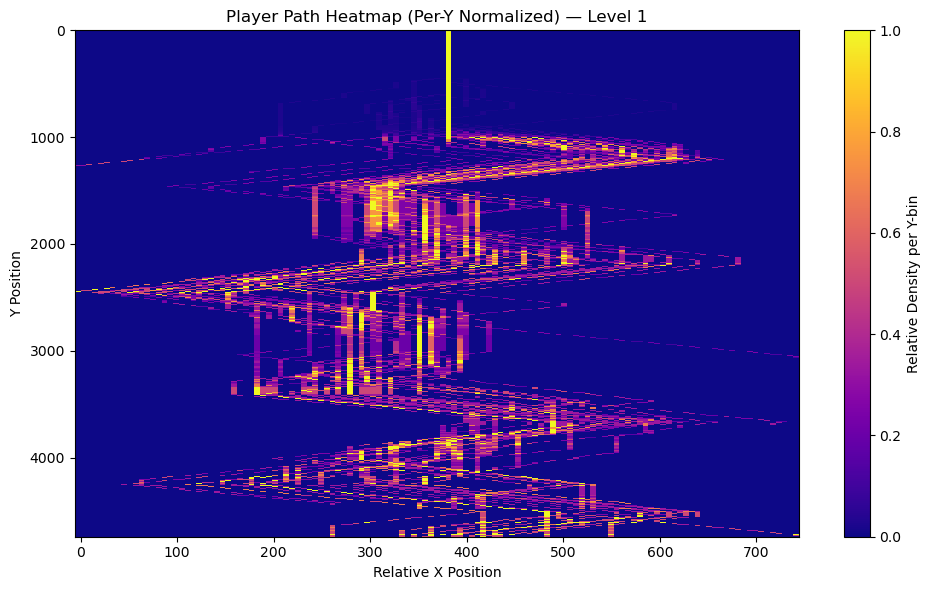

In [59]:

for level, group in corrected_df.groupby('level'):
    plt.figure(figsize=(10, 6))

    # bin widths:
    bin_width_x = 6
    bin_width_y = 6

    # compute bin edges:
    x_min, x_max = group['relative_x'].min(), group['relative_x'].max()
    y_min, y_max = group['y'].min(), group['y'].max()

    x_bins = np.arange(np.floor(x_min), np.ceil(x_max) + bin_width_x, bin_width_x)
    y_bins = np.arange(np.floor(y_min), np.ceil(y_max) + bin_width_y, bin_width_y)

    # 2D histogram:
    counts, xedges, yedges = np.histogram2d(group['relative_x'], group['y'], bins=[x_bins, y_bins])

    # normalize counts within each y-bin (each row)
    counts_normalized = counts / counts.max(axis=0, keepdims=True)
    counts_normalized = np.nan_to_num(counts_normalized)  # replace NaNs from division by zero

    # plot
    X, Y = np.meshgrid(xedges, yedges)

    plt.pcolormesh(X, Y, counts_normalized.T, cmap='plasma', shading='auto')
    plt.gca().invert_yaxis()  # y=0 at the top
    plt.colorbar(label='Relative Density per Y-bin')
    plt.xlabel('Relative X Position')
    plt.ylabel('Y Position')
    plt.title(f"Player Path Heatmap (Per-Y Normalized) — Level {level}")
    plt.tight_layout()
    plt.show()
    
    break


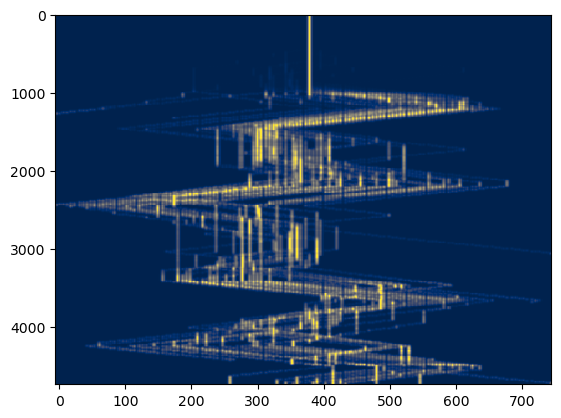

In [10]:
from scipy.ndimage import gaussian_filter

counts, xedges, yedges = np.histogram2d(group['relative_x'], group['y'], bins=[x_bins, y_bins])

# gaussian smoothing
counts_smooth = gaussian_filter(counts, sigma=1)

# per-y normalization
counts_norm = counts_smooth / counts_smooth.max(axis=0, keepdims=True)
counts_norm = np.nan_to_num(counts_norm)

plt.pcolormesh(X, Y, counts_norm.T, cmap='cividis', shading='auto')

plt.gca().invert_yaxis()  # y=0 at the top


In [66]:
sim_dat = pd.read_csv("simulation_output_1_00.csv")

sim_dat["player_pos"] = sim_dat.player_pos.apply(lambda x: literal_eval(x))
player_positions = sim_dat["player_pos"]

x_vals = [pos[0] if isinstance(pos, (list, tuple)) and len(pos) > 0 else np.nan for pos in player_positions]

# drop missing values and keep only the first N values
x_vals = [x for x in x_vals if pd.notna(x)]
sim_dat['x'] = x_vals

# relative_x
sim_dat["last_walls_tile"] = sim_dat.last_walls_tile.apply(lambda x: literal_eval(x))
level_width = 40*scaling  # 40 as fixed variable when generating the levels
sim_dat['relative_x'] = sim_dat.apply(lambda row: level_width - (row['last_walls_tile'][0] - row['x']), axis=1)

# match to y = 0, 5, 10, ... (pixel values), same length as x_vals
y_vals = list(range(0, len(x_vals) * 5, 5))

sim_dat['y'] = y_vals

In [67]:
sim_dat

,trial,attempt,time_played,level_size_y,player_pos,collision,current_input,drift_enabled,current_drift,level_done,visible_obstacles,last_walls_tile,adjacent_wall_tiles_x_pos,visible_drift_tiles,prior,SoC,action_goal_x,x,relative_x,y
0,1,1,0.017161,5418,"[945, -86]",False,Right,True,0.0,False,[],"[1323, 5400]",NaN,[],0.5,0.88,NaN,945,342,0
1,1,1,0.034256,5418,"[945, -82]",False,Right,True,0.0,False,[],"[1323, 5400]",NaN,[],0.5,0.88,NaN,945,342,5
2,1,1,0.056291,5418,"[945, -78]",False,Right,True,0.0,False,[],"[1323, 5400]",NaN,[],0.5,0.88,NaN,945,342,10
3,1,1,0.067169,5418,"[945, -74]",False,Right,True,0.0,False,[],"[1323, 5400]",NaN,[],0.5,0.88,NaN,945,342,15
4,1,1,0.084395,5418,"[945, -70]",False,Right,True,0.0,False,[],"[1323, 5400]",NaN,[],0.5,0.88,NaN,945,342,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
882,1,1,14.641393,5418,"[945, 270]",False,Left,True,1.0,False,"[[819, 300], [1233, 282], [1179, 246], [927, 2...","[1491, 636]",NaN,"[[1567, 120]]",0.5,0.88,966.0,945,174,4410
883,1,1,14.658498,5418,"[945, 270]",False,Left,True,1.0,False,"[[825, 294], [1239, 276], [1185, 240], [933, 2...","[1497, 630]",NaN,"[[1573, 114]]",0.5,0.88,966.0,945,168,4415
884,1,1,14.674810,5418,"[945, 270]",False,Left,True,1.0,False,"[[831, 288], [1245, 270], [1191, 234], [939, 2...","[1503, 624]",NaN,"[[1579, 108]]",0.5,0.88,966.0,945,162,4420
885,1,1,14.690657,5418,"[945, 270]",True,Left,True,1.0,False,"[[837, 282], [1251, 264], [1197, 228], [945, 2...","[1509, 618]",NaN,"[[1585, 102]]",0.5,0.88,966.0,945,156,4425
